# Transmitter Playground

This playground is intended to demonstrate the expected behavior of the Transmitter module across different decision-making environments.

As described in the module's own README, the Transmitter is an adaptive probabilistic system designed to operate under uncertainty without imposing a predefined deterministic structure over the decision space. Rather than starting from arbitrary initial configurations, the Transmitter begins from a state of complete symmetry in which all decisions are equally probable and, through accumulated experience, progressively reorganizes this distribution to favor those regions of the space that produce better outcomes.

To observe this behavior in a controlled manner, the Transmitter is exposed throughout this playground to a series of reward functions with different properties and levels of difficulty. In each case, the system performs an iterative process of sampling and feedback through which it must dynamically modify its probability distribution in order to approximate the regions that maximize the expected reward.

This progression is organized through the following environments:
- Two-level step function.
- Three-level step function.
- Linear function.
- Quadratic function.
- Multimodal function.

The sequence of experiments allows the analysis, in an incremental way, of different aspects of the Transmitter's behavior: its exploration capabilities, its stability, its progressive adaptation to experience, and its tendency to concentrate probability around optimal regions of the decision space.

Finally, the playground also analyzes how the introduction of dynamic sampling biases makes it possible to modify the balance between exploration and exploitation without directly altering the probability distribution learned by the system.

In [1]:
import math

import matplotlib.pyplot as plt

from jacinta.transmitter import Transmitter
from jacinta.utils.scheduler import ConstantScheduleStrategy, Scheduler

## Getting Started

One of the fundamental principles behind the design of Jacinta is to minimize, as much as possible, the dependence on highly specific hyperparameter configurations. The goal is not to find an optimal parametrization for each particular environment, but rather to build a system whose emergent behavior remains relatively stable under reasonable configurations.

For this reason, all experiments in this playground use a simple and constant set of hyperparameters that, while not specifically optimized, is sufficient to observe the expected behavior of the system.

More specifically, the configurations used are the following:
- The Transmitter decision space is defined over the interval $[-10, 10)$.
- The learning rate remains constant with a value of $0.0001$. This allows each level of the tree enough time to progressively stabilize its probability distribution.
- The tree split rate remains constant with a value of $1000$. This allows each level of the tree to reach a relatively stable state before increasing the resolution of the decision space.
- The bias applied during sampling is set to $0.0$, thereby favoring the behavior learned by the distribution without introducing additional external preferences.

Throughout the playground, these configurations remain fixed unless explicitly stated otherwise.

In [2]:
INTERVAL = (-10, 10)

LEARNING_RATE = 0.0001
HITS_RATE = 1000

MAX_STEPS = 100000
N_POINTS = 5000
N_PLOTS = 5

SEED = 42

## Environment Definition

Subjecting the Transmitter to a reward function is, in practical terms, equivalent to placing it in an environment in which certain decisions favor its survival while others hinder it. The reward function therefore acts as the mechanism through which the environment evaluates the decisions made by the system.

This framework becomes especially natural when interpreted from a biological perspective. In a living organism, actions such as feeding, avoiding pain, or conserving energy generate internal signals that reinforce or penalize certain behaviors. Through this process, the organism progressively learns which decisions increase its chances of survival.

This playground uses precisely a simplified version of such an environment based on feeding behavior. The Transmitter is positioned on a one-dimensional horizontal axis and must decide toward which position to move in order to obtain food. Depending on the selected region of the space, the environment returns a positive, negative, or neutral reward, respectively simulating beneficial food, harmful food, or the absence of food.

Each of the reward functions presented below defines a different distribution of these stimuli over the decision space. As a consequence, the Transmitter must dynamically reorganize its probability distribution in order to progressively adapt to each specific environment.

> **Note:** This playground exclusively evaluates the isolated behavior of the Transmitter module. Consequently, the environment does not evolve as a result of the decisions made by the system. After each iteration, the state of the environment remains unchanged and the Transmitter is once again confronted with exactly the same decision problem. More complex dynamic scenarios, in which decisions modify the environment or generate cumulative consequences over time, are evaluated in the Receiver module playground.

In [3]:
def plot_transmitter_distribution(
    ax: plt.Axes, transmitter: Transmitter, interval: tuple[float], title: str = ""
) -> None:
    """
    Plot the Transmitter distribution.

    Args:
        ax (plt.Axes): The axes to plot on.
        transmitter (Transmitter): The Transmitter to plot.
        interval (tuple[float]): The interval to plot the distribution over.
        title (str): The title of the plot. Defaults to "".
    """
    # only leaves are used to plot the distribution
    leaves = [node for node in transmitter.nodes if node.is_leaf]
    if leaves:
        # get the maximum log-mass for numerical stability
        m = max(node.log_mass for node in leaves)
        # compute the shifted mass sum in normal space
        total_norm_mass = sum(math.exp(node.log_mass - m) for node in leaves)
        # recover the log of the total mass using log-sum-exp
        total_log_mass = m + math.log(total_norm_mass)
        for node in leaves:
            # convert log-mass into normalized probability mass
            normalized_mass = math.exp(node.log_mass - total_log_mass)
            # convert probability mass into probability density
            height = normalized_mass / node.length
            ax.bar(
                node.left,
                height,
                width=node.length,
                align="edge",
                alpha=0.6,
                edgecolor="black",
                linewidth=1,
                color="C0",
            )
    # general plot settings
    ax.set_xlim(interval[0], interval[1])
    ax.set_xlabel("Decision Space")
    ax.set_ylabel("Probability Density")
    ax.set_title(f"{title} Transmitter Distribution".strip())
    ax.grid(True, linewidth=0.8, alpha=0.3)
    return

In [4]:
def plot_target_distribution(
    ax: plt.Axes, func: callable, interval: tuple[float], n_points: int
) -> None:
    """
    Plot the target distribution.

    Args:
        ax (plt.Axes): The axes to plot on.
        func (callable): The function to plot.
        interval (tuple[float]): The interval to plot the distribution over.
        n_points (int): The number of points to plot.
    """
    # evaluate the target distribution over the given interval
    step = (interval[1] - interval[0]) / (n_points - 1)
    xs = [interval[0] + point * step for point in range(n_points)]
    ys = [func(x) for x in xs]
    # detect global minimums & maximums
    y_min = min(ys)
    y_max = max(ys)
    min_indices = [idx for idx, y in enumerate(ys) if y == y_min]
    max_indices = [idx for idx, y in enumerate(ys) if y == y_max]
    # plot the target distribution
    ax.plot(xs, ys, color="C1", linewidth=1)
    # plot global minimums and maximums
    ax.scatter(xs[min_indices[0]], y_min, color="C1")
    ax.scatter(xs[max_indices[0]], y_max, color="C1")
    ax.axhline(y=y_min, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.axhline(y=y_max, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.annotate(
        f"({xs[min_indices[0]]:.2f}, {y_min:.2f})",
        (xs[min_indices[0]], y_min),
        textcoords="offset points",
        xytext=(2, 2),
    )
    ax.annotate(
        f"({xs[max_indices[0]]:.2f}, {y_max:.2f})",
        (xs[max_indices[0]], y_max),
        textcoords="offset points",
        xytext=(2, 2),
    )
    # general plot settings
    ax.set_xlim(interval[0], interval[1])
    ax.set_xlabel("x")
    ax.set_ylabel("R(x)")
    ax.set_title("Feedback Function")
    ax.grid(True, linewidth=0.8, alpha=0.3)
    return

In [5]:
def run(func: callable) -> None:
    """
    Run the Transmitter for a given function.

    Args:
        func (callable): The function to run.
    """
    lr_scheduler = Scheduler(ConstantScheduleStrategy(LEARNING_RATE))
    hits_scheduler = Scheduler(ConstantScheduleStrategy(HITS_RATE))
    transmitter = Transmitter(
        INTERVAL[0], INTERVAL[1], lr_scheduler, hits_scheduler, seed=SEED
    )
    for step in range(MAX_STEPS + 1):
        # forward & backward pass
        sample = transmitter.forward()
        feedback = func(sample.value)
        transmitter.backward(sample, feedback)
        # plot the Transmitter distribution
        if step % (MAX_STEPS // N_PLOTS) == 0:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
            plot_transmitter_distribution(ax1, transmitter, INTERVAL)
            plot_target_distribution(ax2, func, INTERVAL, N_POINTS)
            plt.suptitle(f"{step}/{MAX_STEPS} Steps")
            plt.tight_layout()
            plt.show()
    return

### Two-Level Step Function

This is the simplest possible environment. The Transmitter is positioned at the center of the horizontal axis and must decide whether to move to the left or to the right. Beneficial food is located on the right side, while harmful food is located on the left side.

As a consequence, any decision located within the positive region of the space produces a positive reward, whereas any decision located within the negative region produces a negative reward. The reward function used is therefore the following:

$$
R(x) : [-10, 10) \to [-1, 1]
$$

$$
R(x) =
\begin{cases}
1 & \text{if } x \ge 0 \\
-1 & \text{if } x < 0
\end{cases}
$$

In [6]:
def func(x: float) -> float:
    """
    Two-level step function.

    Args:
        x (float): The input value.

    Returns:
        float: The output value.
    """
    y = 1.0 if x >= 0.0 else -1.0
    return y

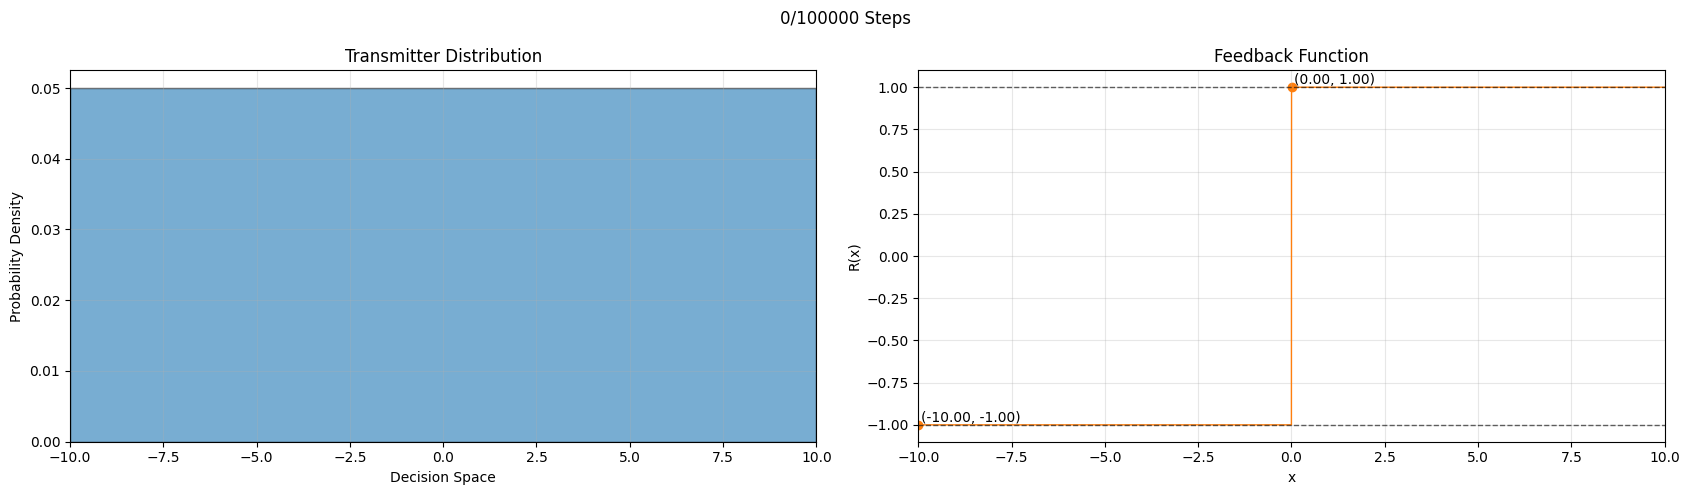

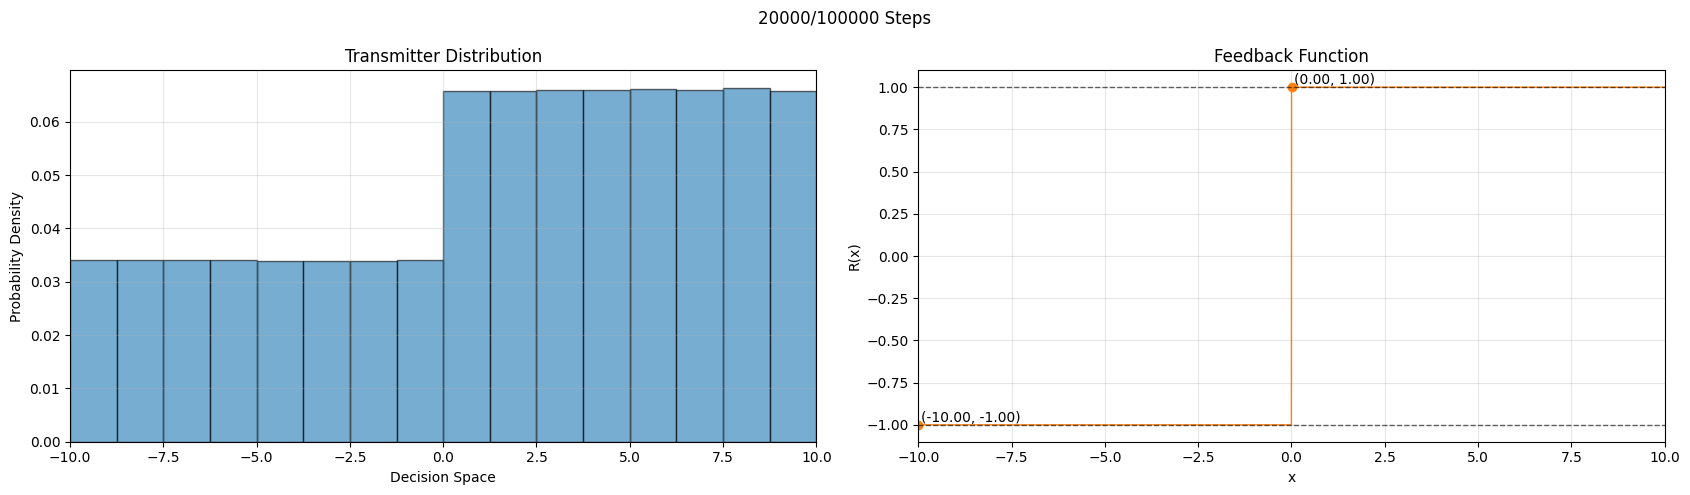

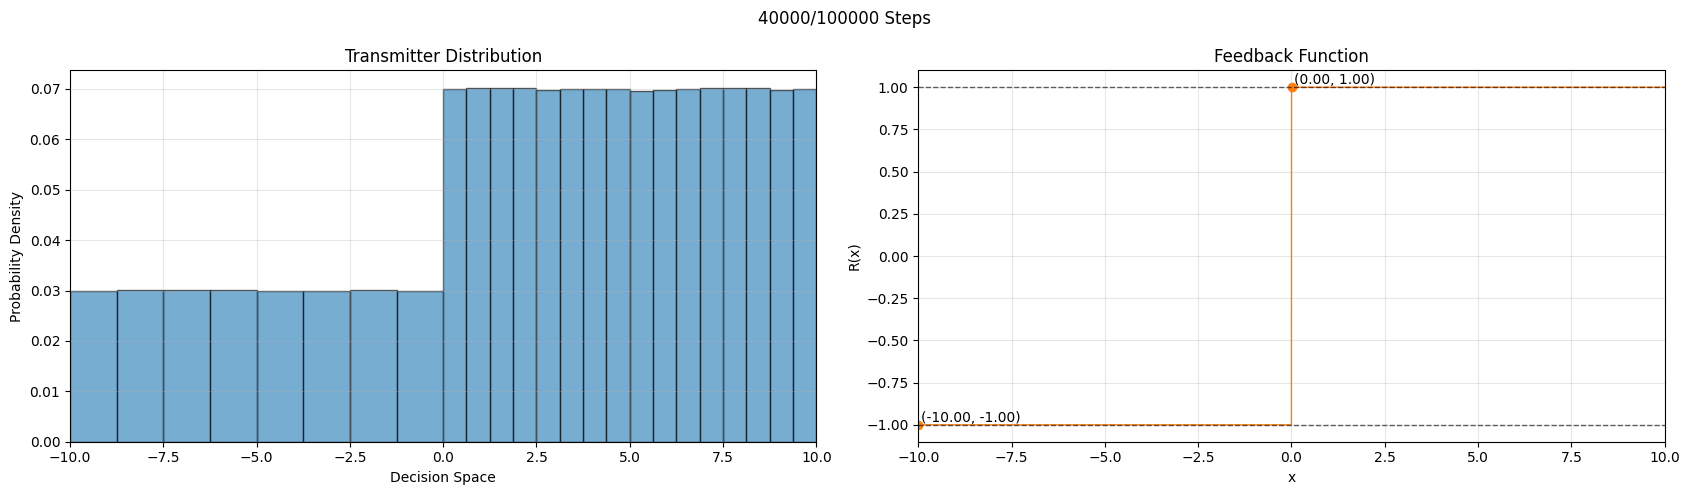

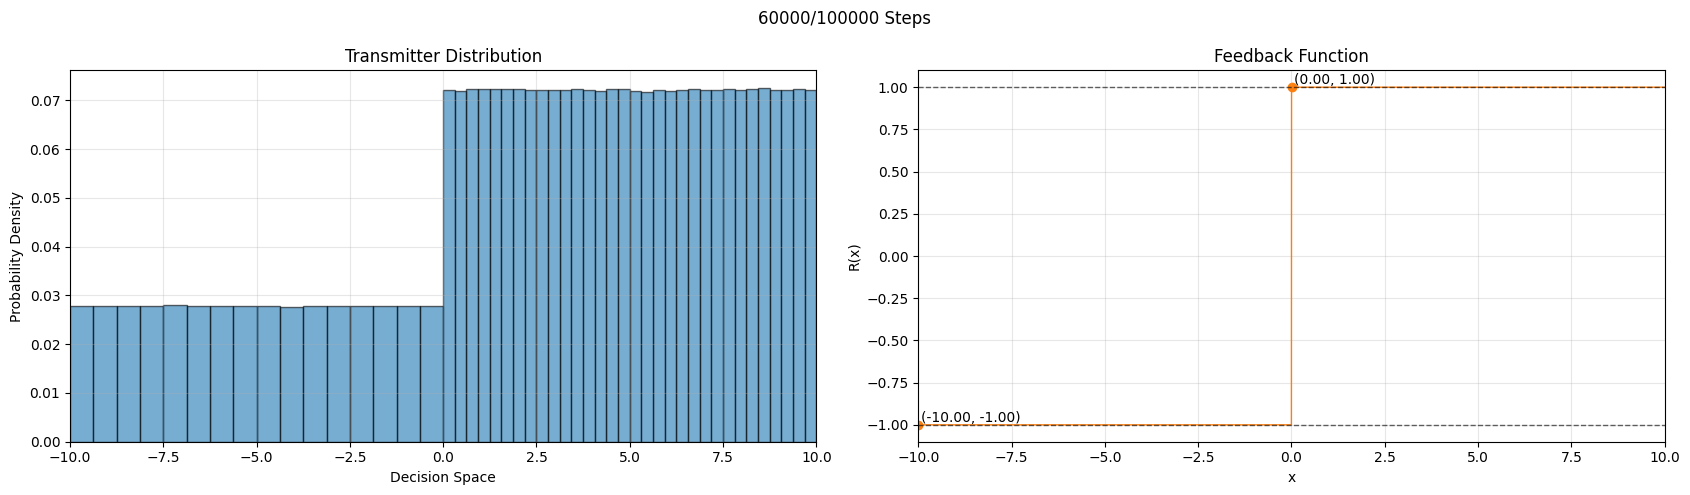

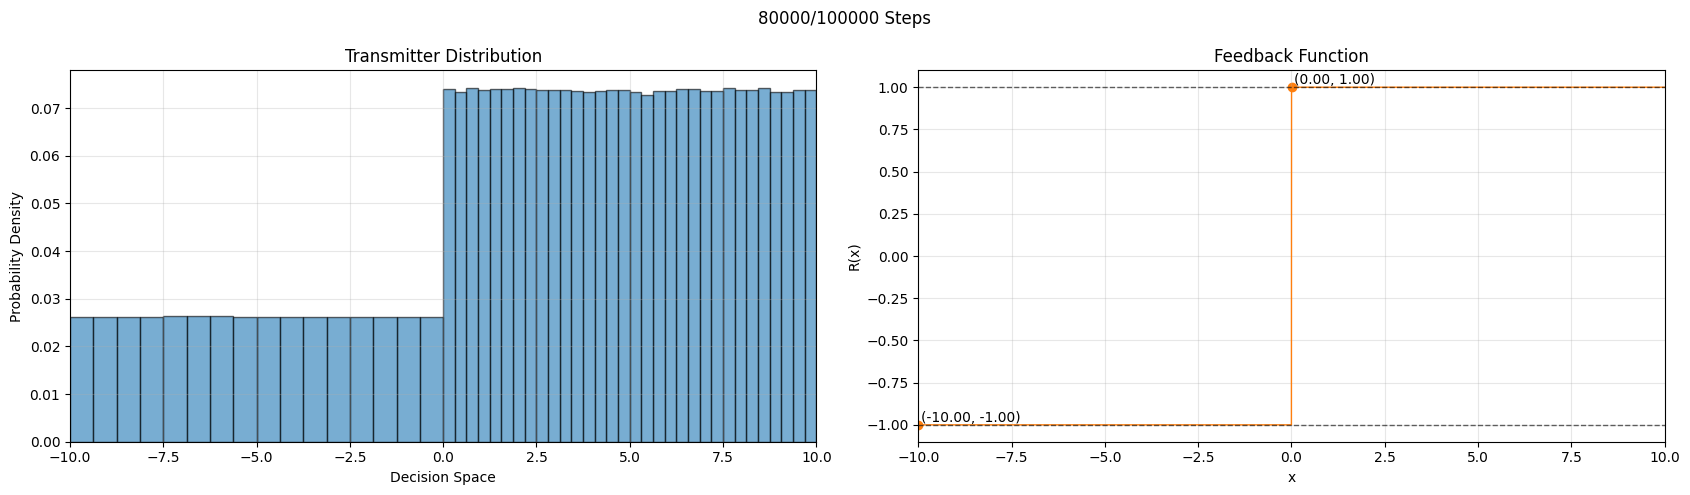

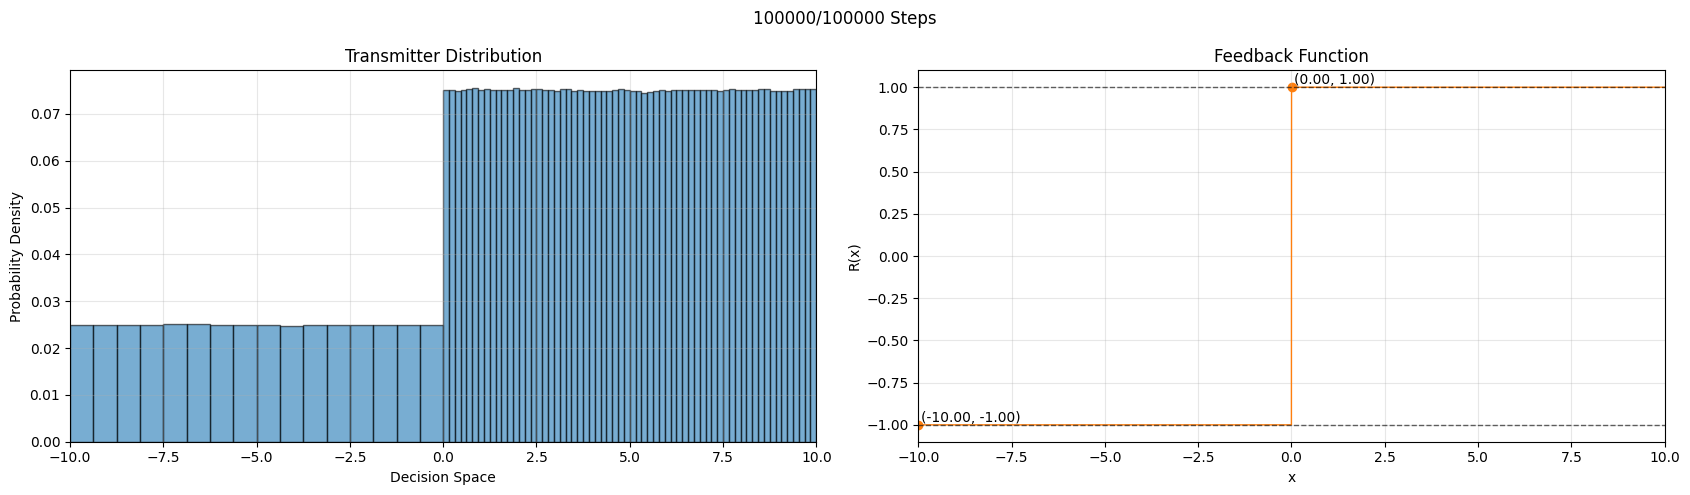

In [7]:
run(func)

### Three-Level Step Function

The previous environment forces the Transmitter to choose between two clearly differentiated alternatives: moving toward a favorable region or moving toward a harmful region. However, there is also a third possibility: remaining still.

From the perspective of the environment, remaining still implies giving up both beneficial and harmful food. As a consequence, this situation produces a neutral reward.

Since the decision space is continuous, the action of remaining still is represented by a small region around the origin. More specifically, the Transmitter is considered to remain still when the selected decision belongs to the interval $[-2.5, 2.5]$.

The reward function used is therefore the following:

$$
R(x) : [-10, 10) \to [-1, 1]
$$

$$
R(x) =
\begin{cases}
1 & \text{if } x > 2.5 \\
0 & \text{if } -2.5 \le x \le 2.5 \\
-1 & \text{if } x < -2.5
\end{cases}
$$

In [8]:
def func(x: float) -> float:
    """
    Three-level step function.

    Args:
        x (float): The input value.

    Returns:
        float: The output value.
    """
    if x > 2.5:
        y = 1.0
    elif x >= -2.5:
        y = 0.0
    else:
        y = -1.0
    return y

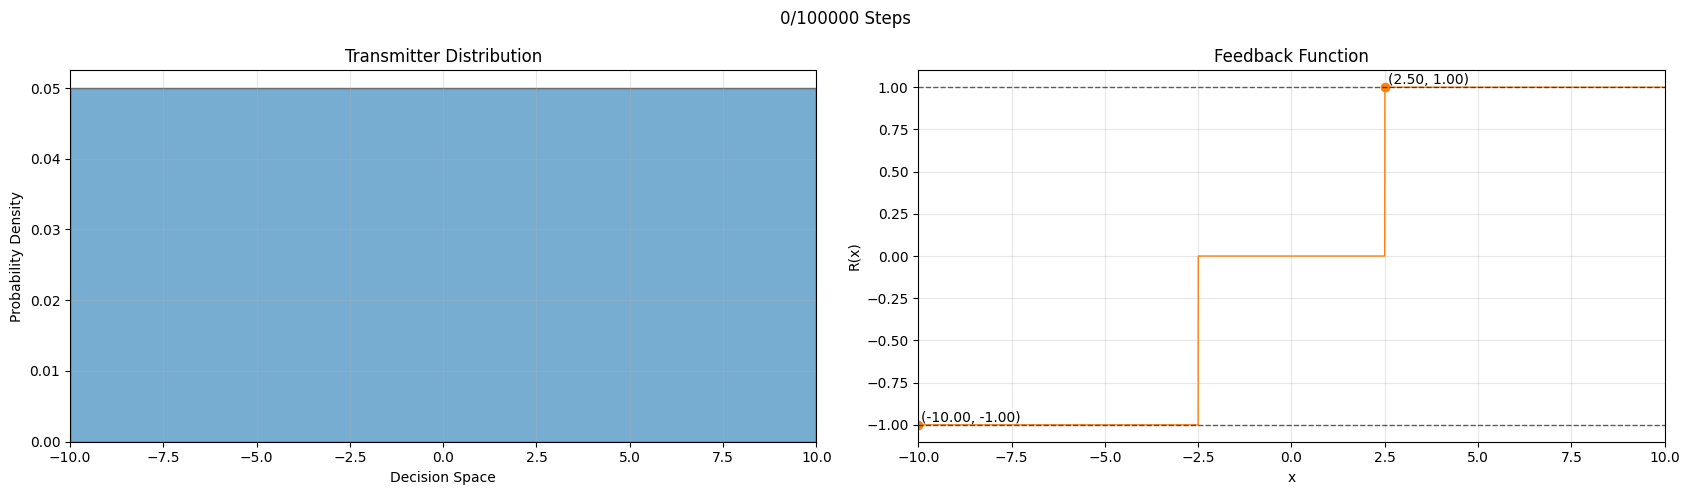

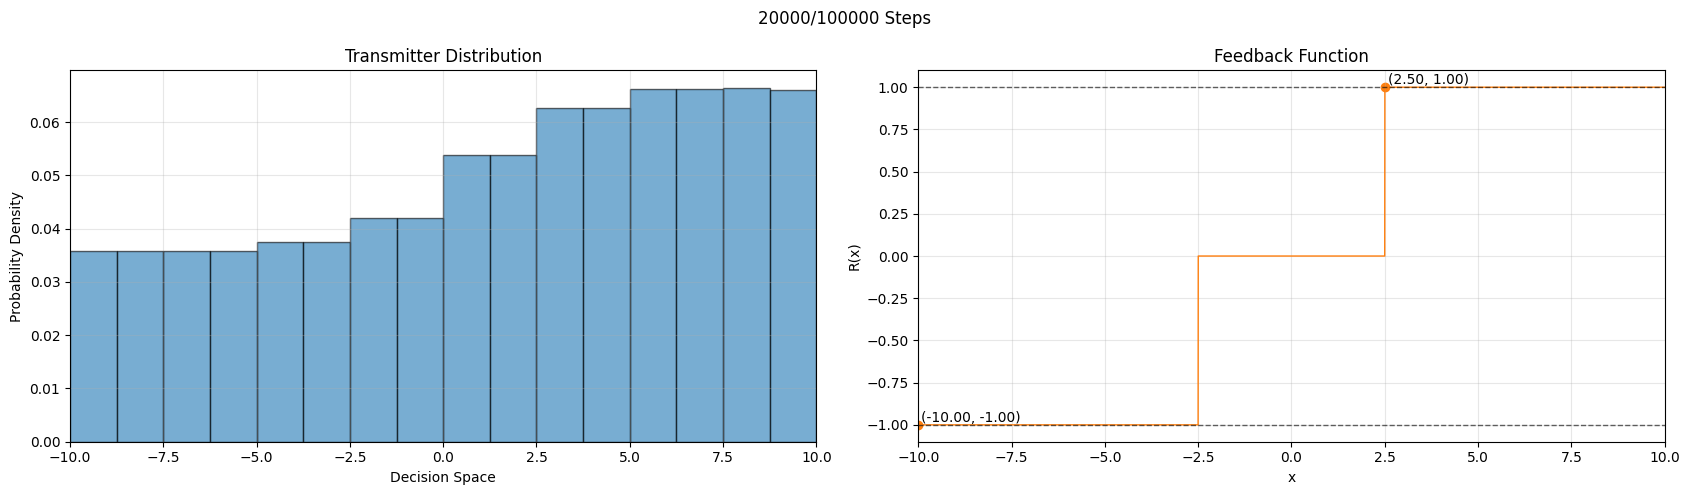

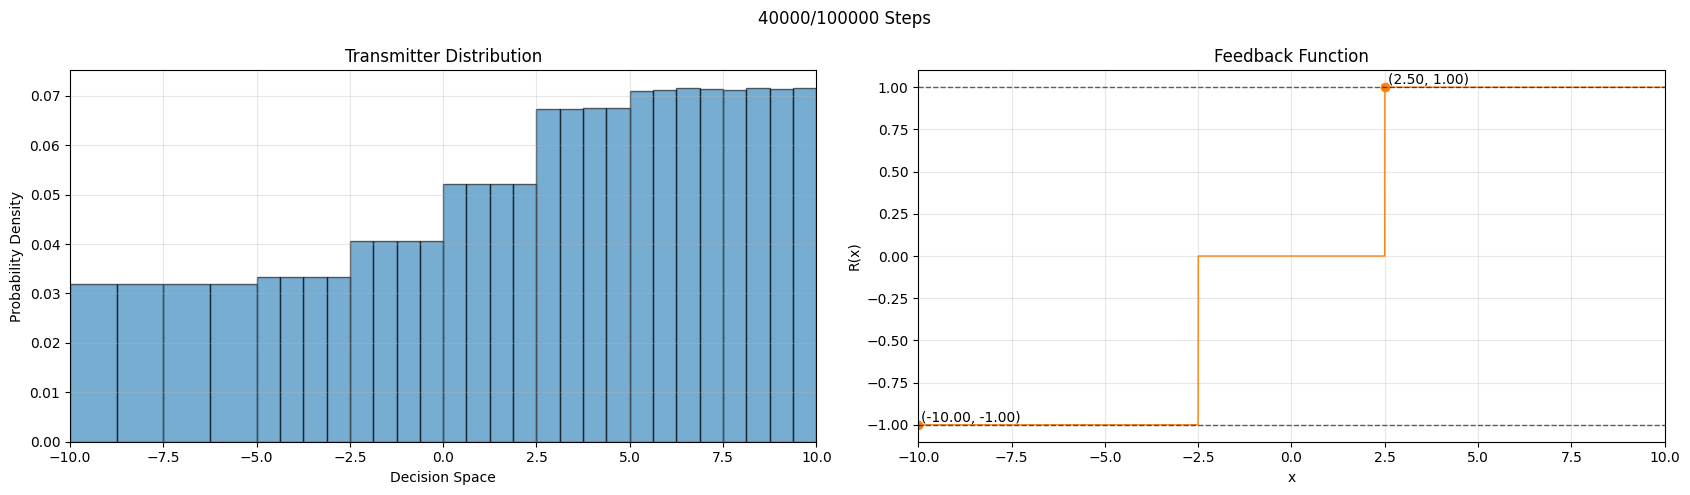

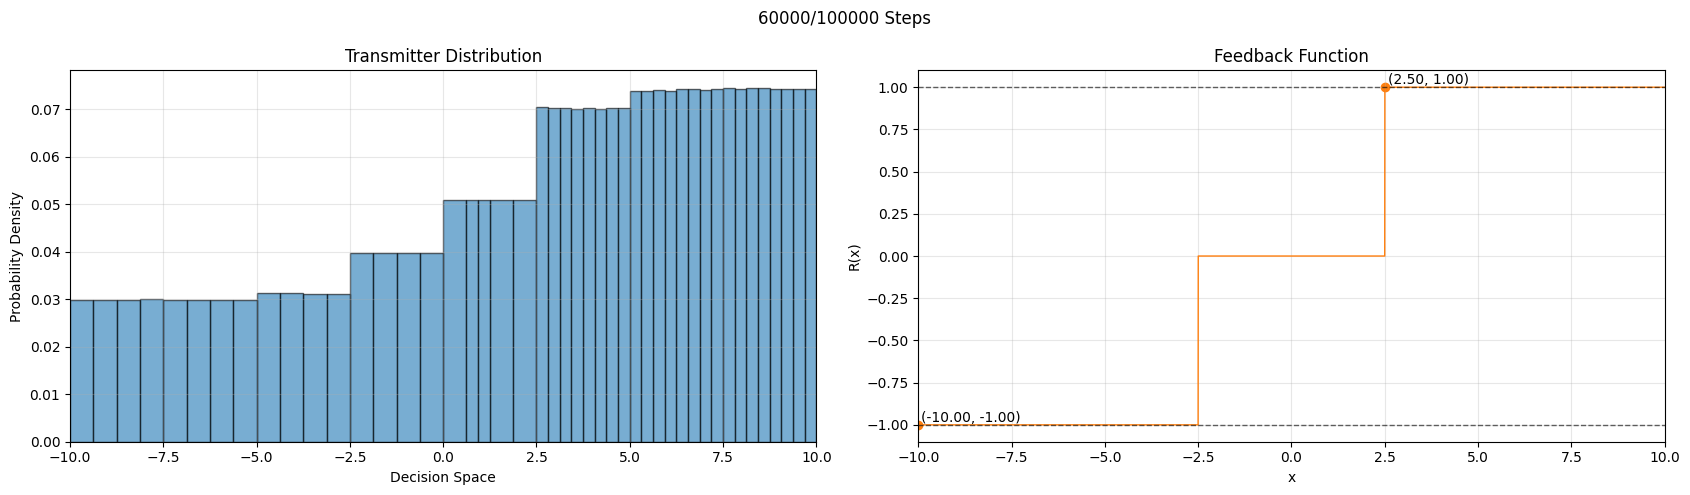

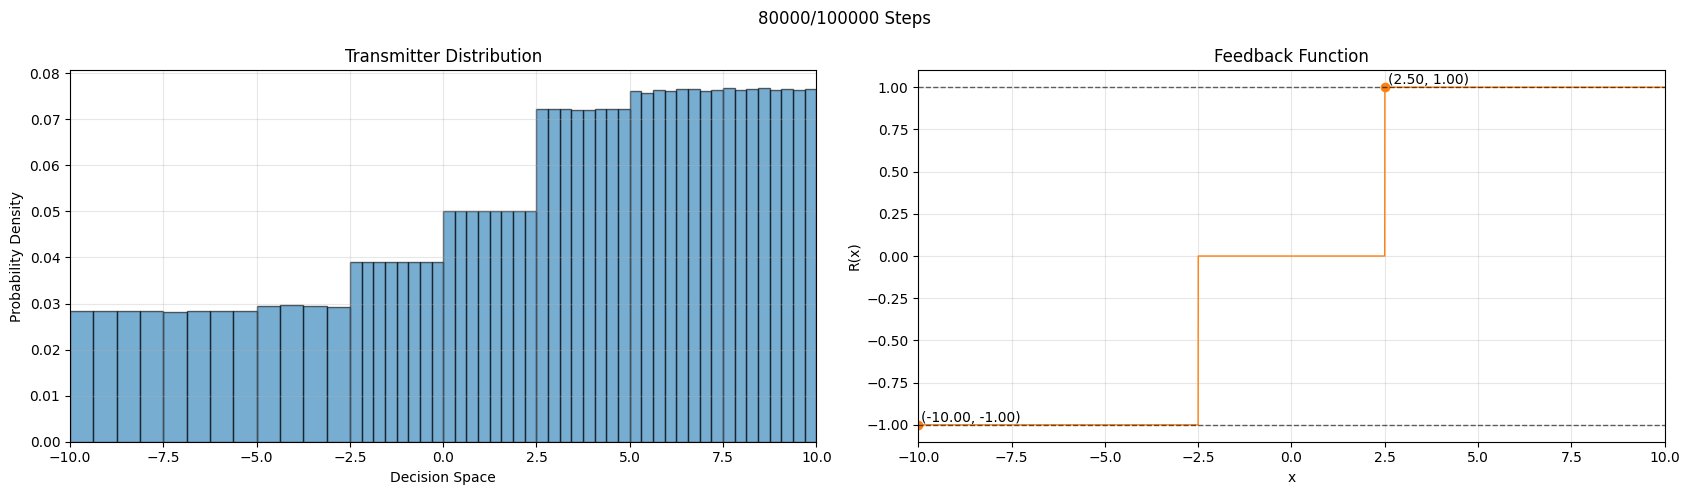

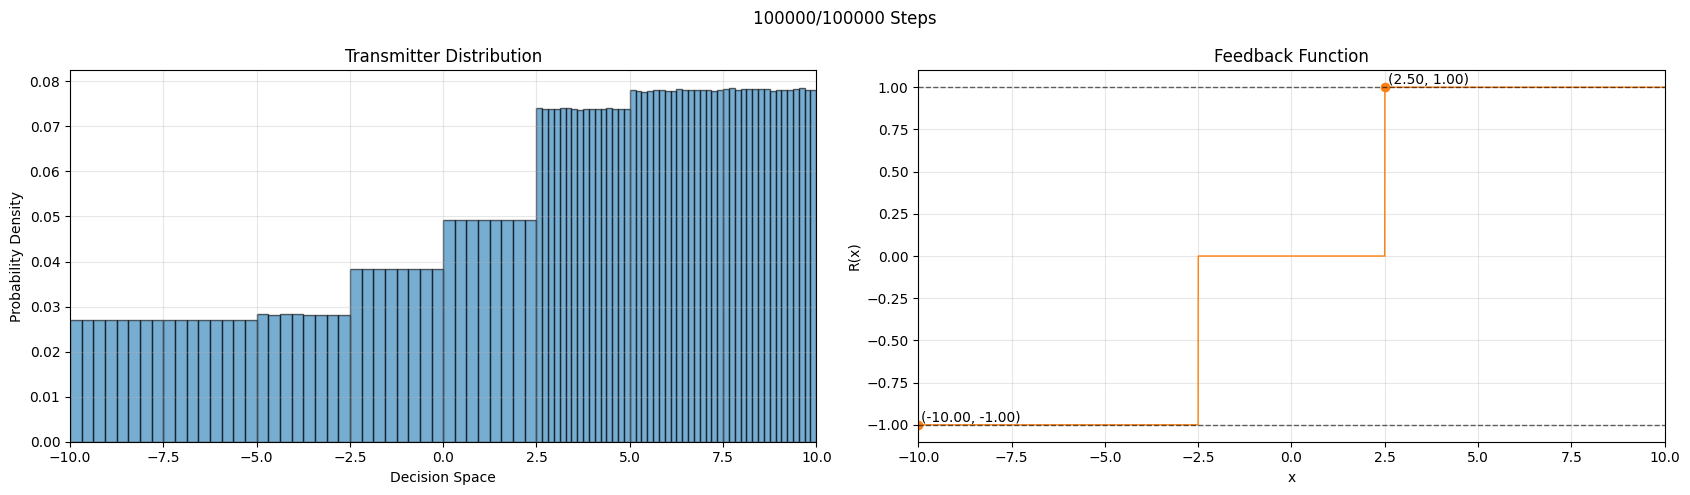

In [9]:
run(func)

### Linear Function

The previous environments only distinguish between favorable, neutral, and harmful regions. However, the exact magnitude of the selected decision does not influence the obtained reward. Any decision within the same region produces exactly the same outcome.

In a more realistic environment, this is no longer true. If food is progressively distributed across the space, moving a greater distance allows access to a larger amount of food. As a consequence, the reward no longer depends solely on the direction of the movement, but also on its magnitude.

To represent this behavior, a linear reward function is defined over the decision space:

$$
R(x) : [-10, 10) \to [-1, 1]
$$

$$
R(x) = \frac{x}{10}
$$

In [10]:
def func(x: float) -> float:
    """
    Linear function.

    Args:
        x (float): The input value.

    Returns:
        float: The output value.
    """
    y = x / 10.0
    return y

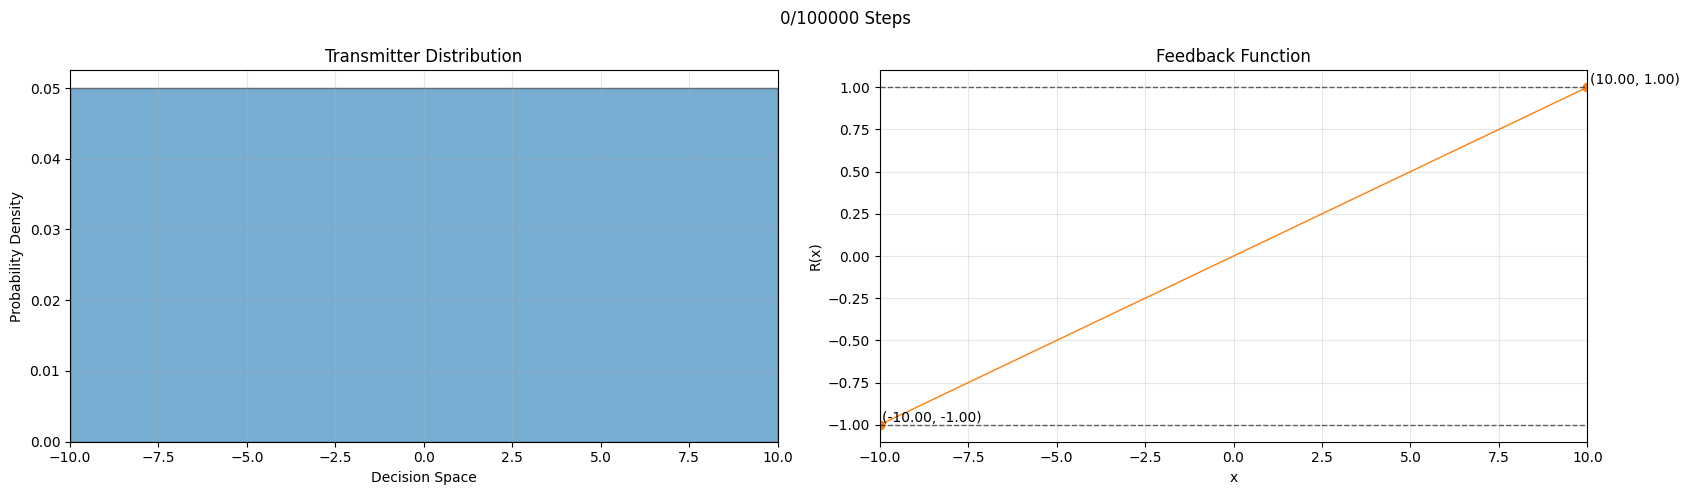

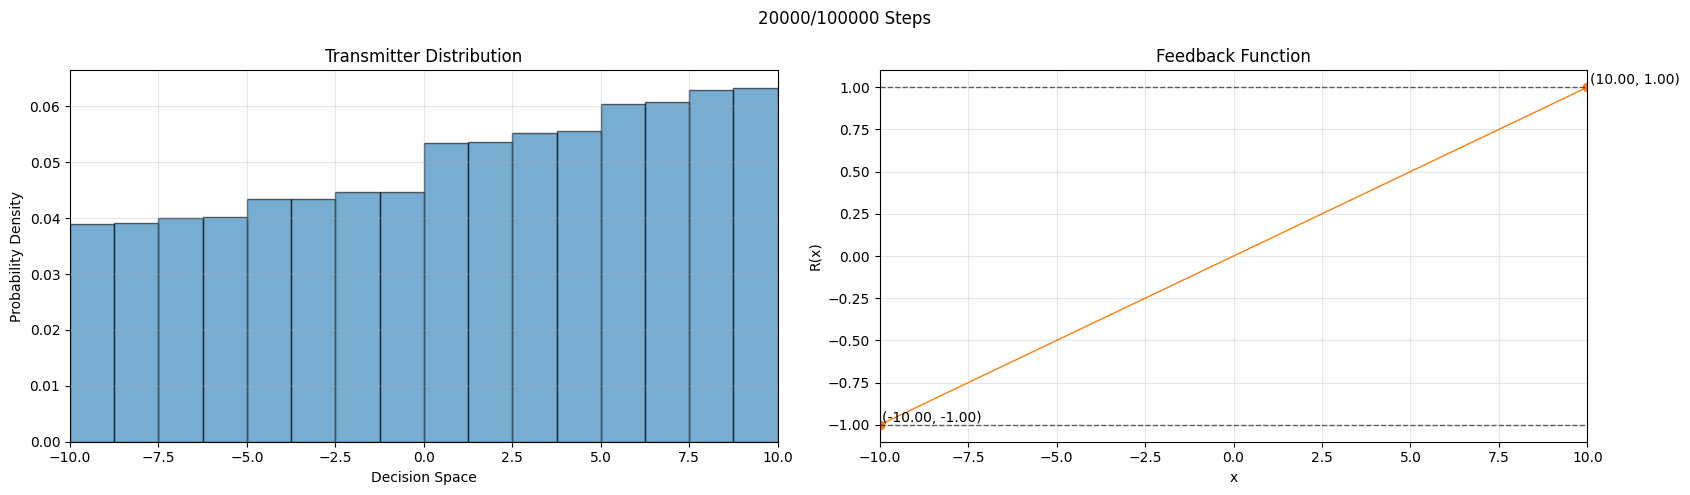

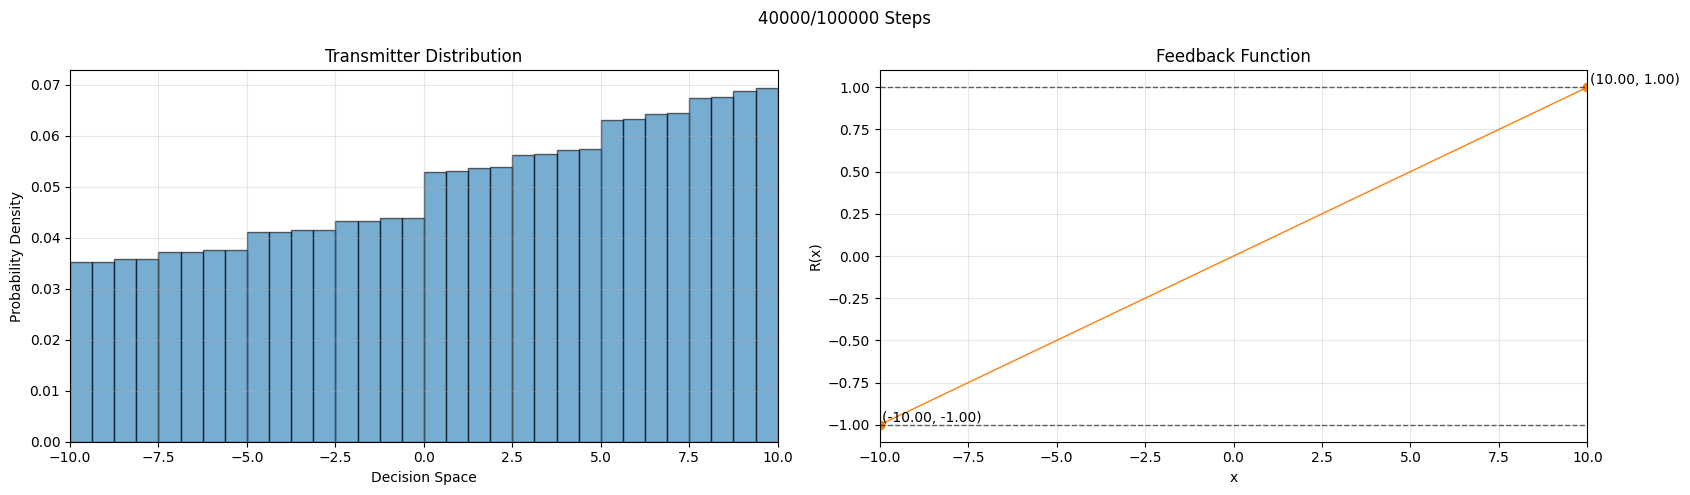

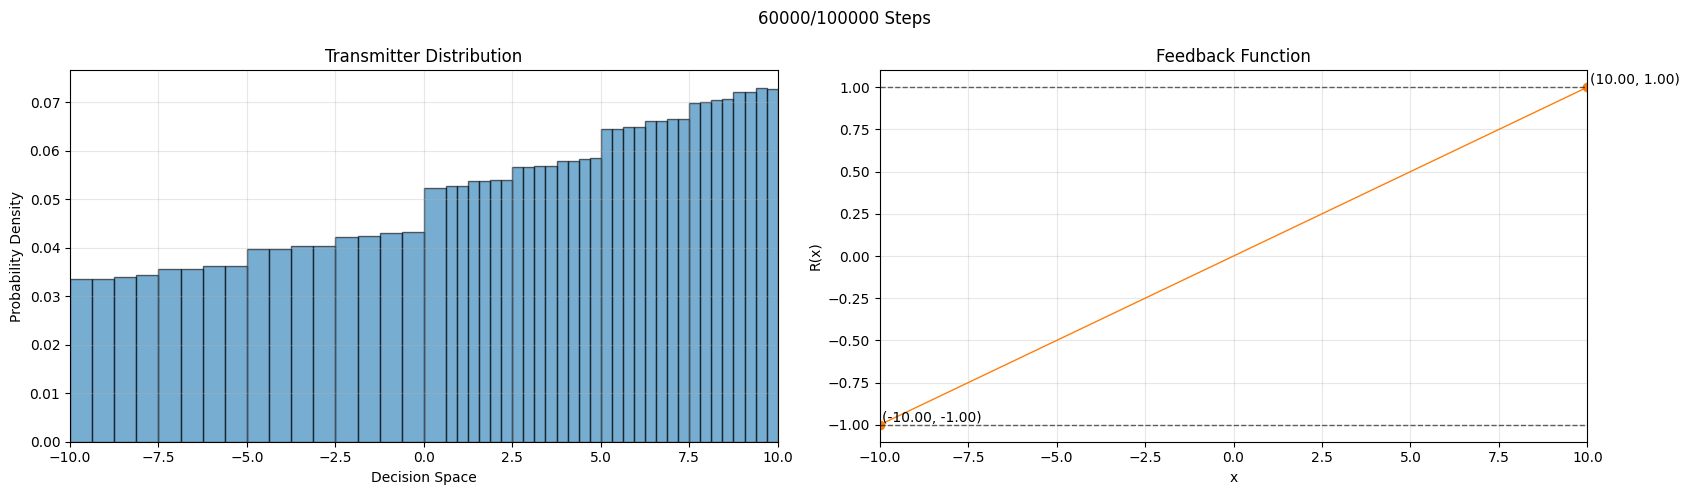

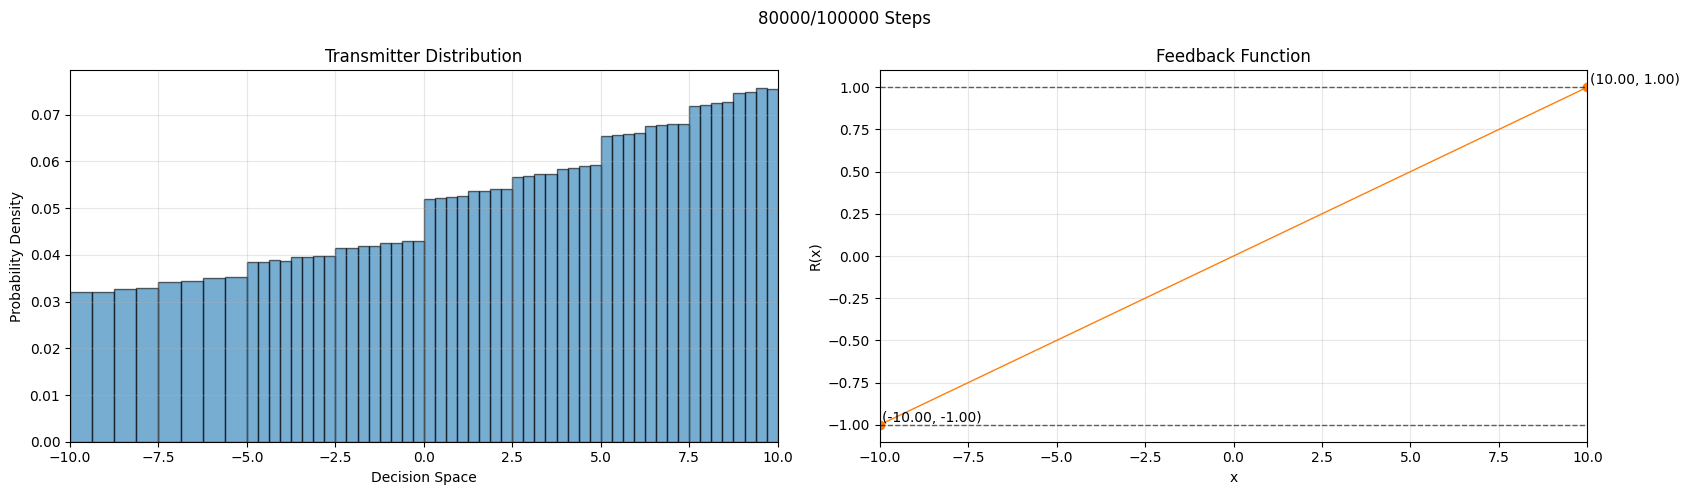

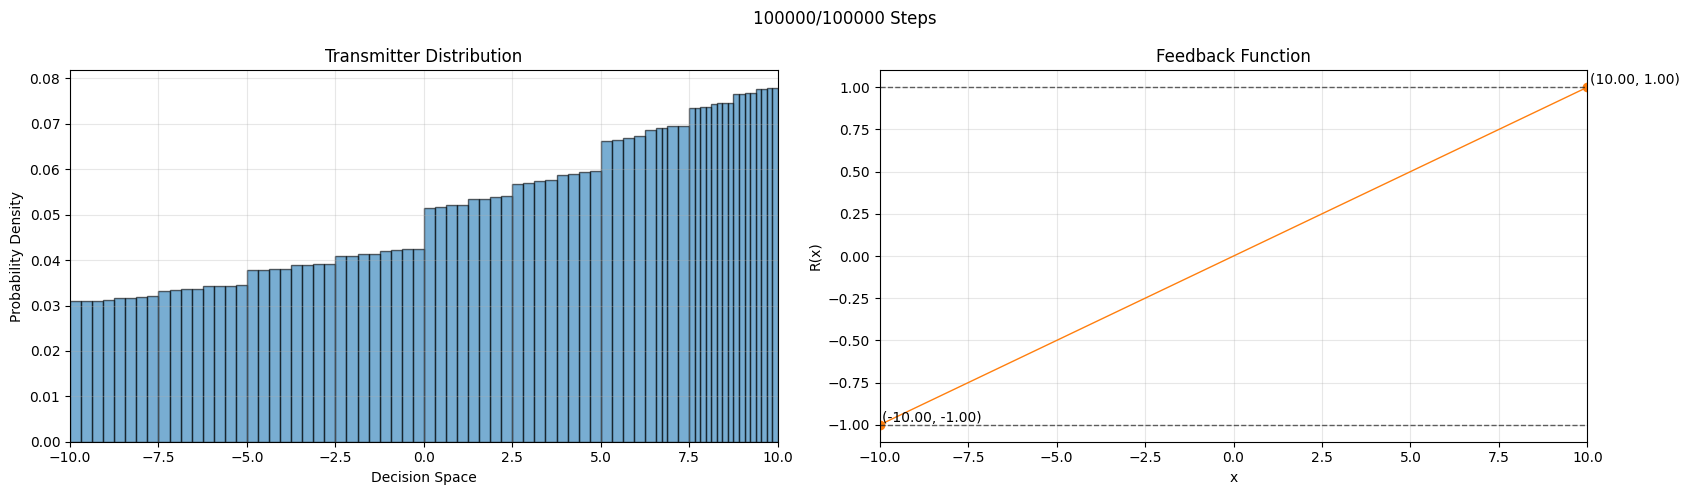

In [11]:
run(func)

### Quadratic Function

In the previous environments, the reward structure systematically favors a single direction of movement. However, this does not necessarily have to be the case. It is possible to define environments in which multiple distinct regions of the space produce equally favorable rewards.

To represent this situation, a positive quadratic function is used:

$$
R(x) : [-10, 10) \to [0, 1]
$$

$$
R(x) = \left(\frac{x}{10}\right)^2
$$

In this case, both the positive and negative regions of the space produce favorable rewards. As a consequence, decisions farther away from the origin become progressively more beneficial regardless of their direction.

In [12]:
def func(x: float) -> float:
    """
    Positive quadratic function.

    Args:
        x (float): The input value.

    Returns:
        float: The output value.
    """
    y = (x / 10.0) ** 2
    return y

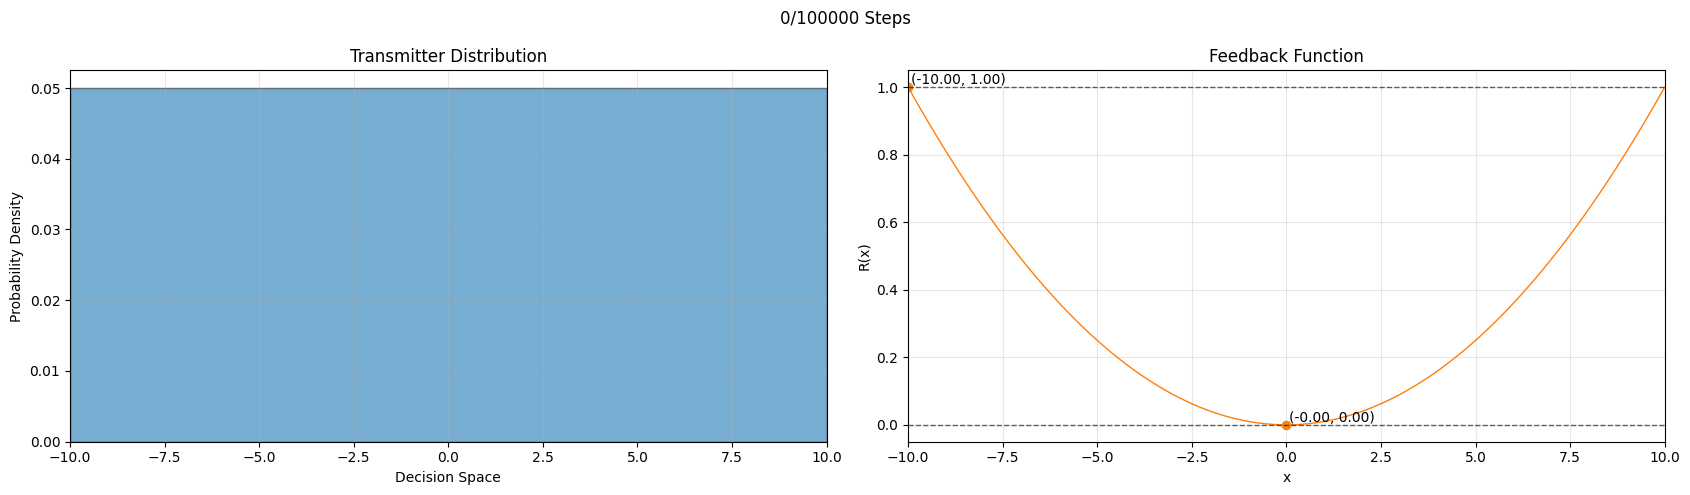

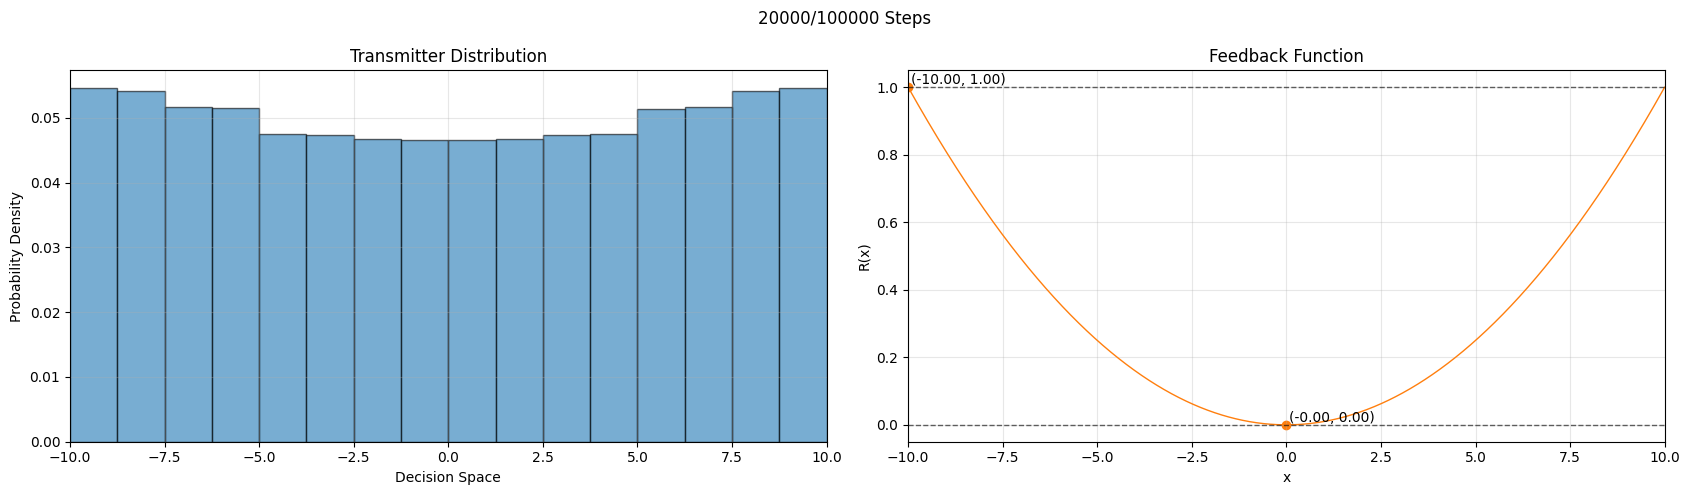

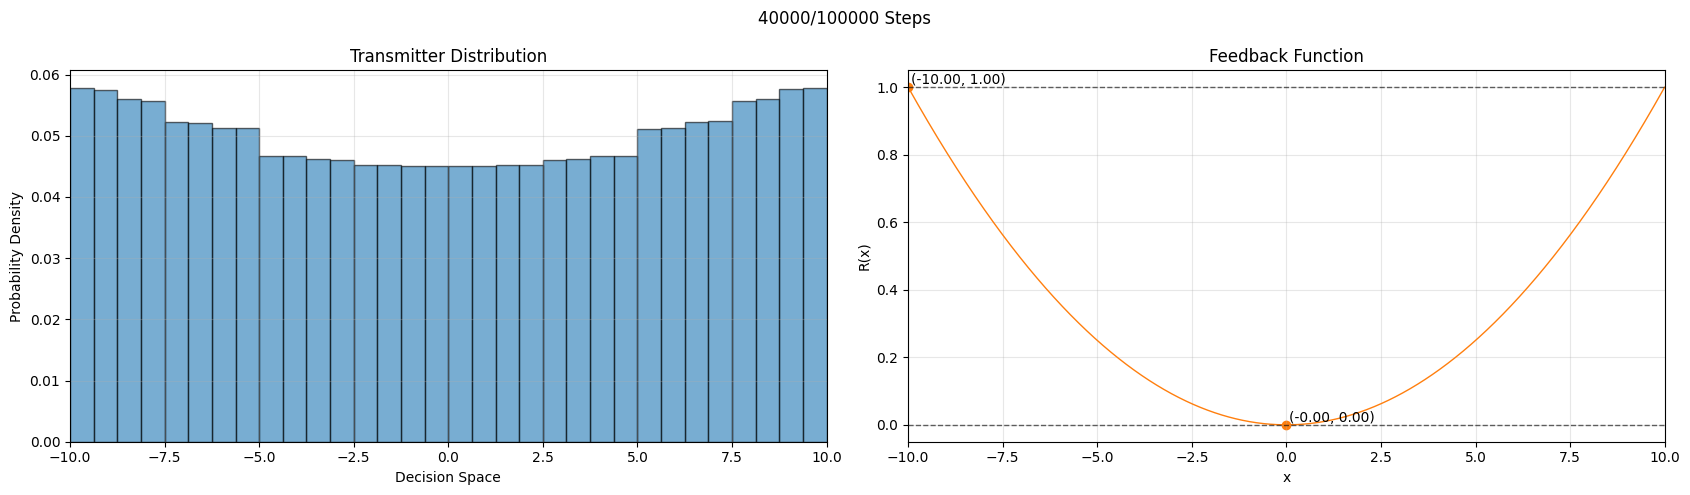

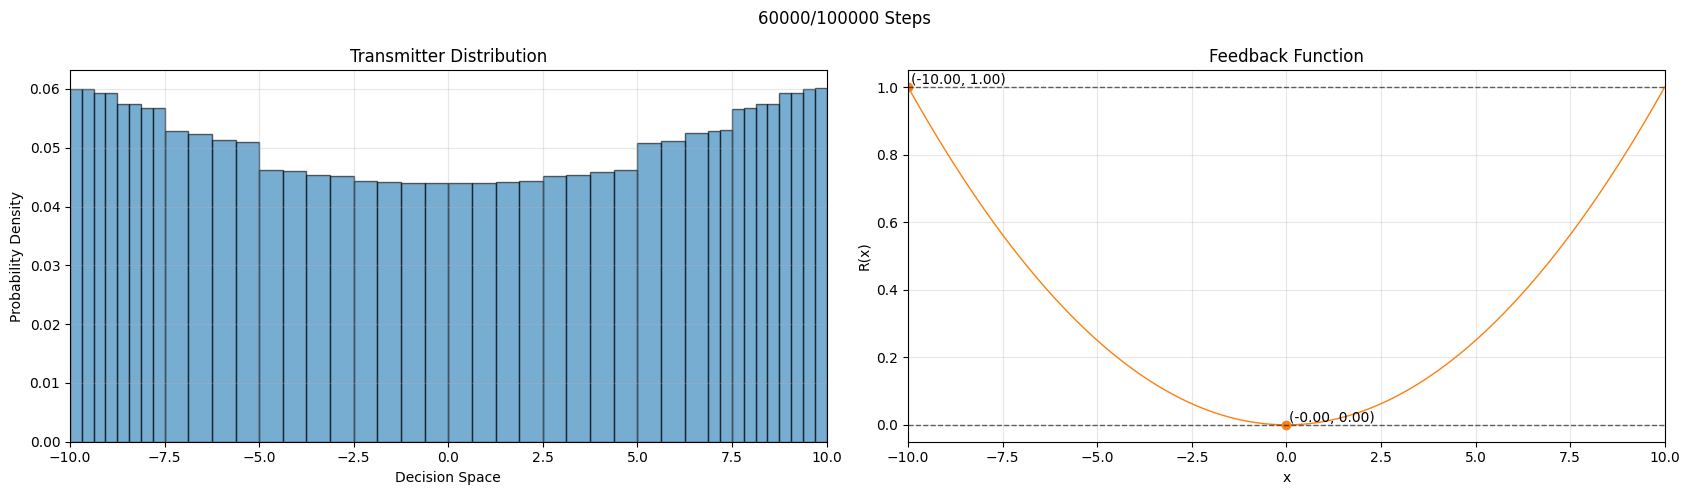

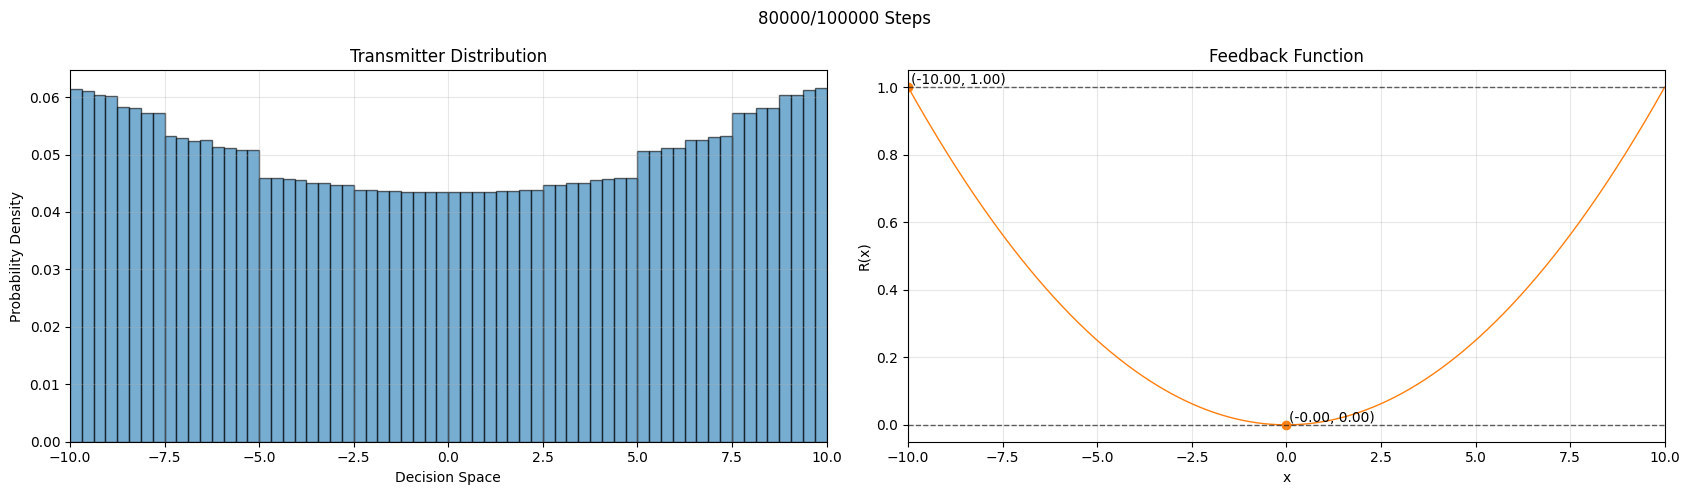

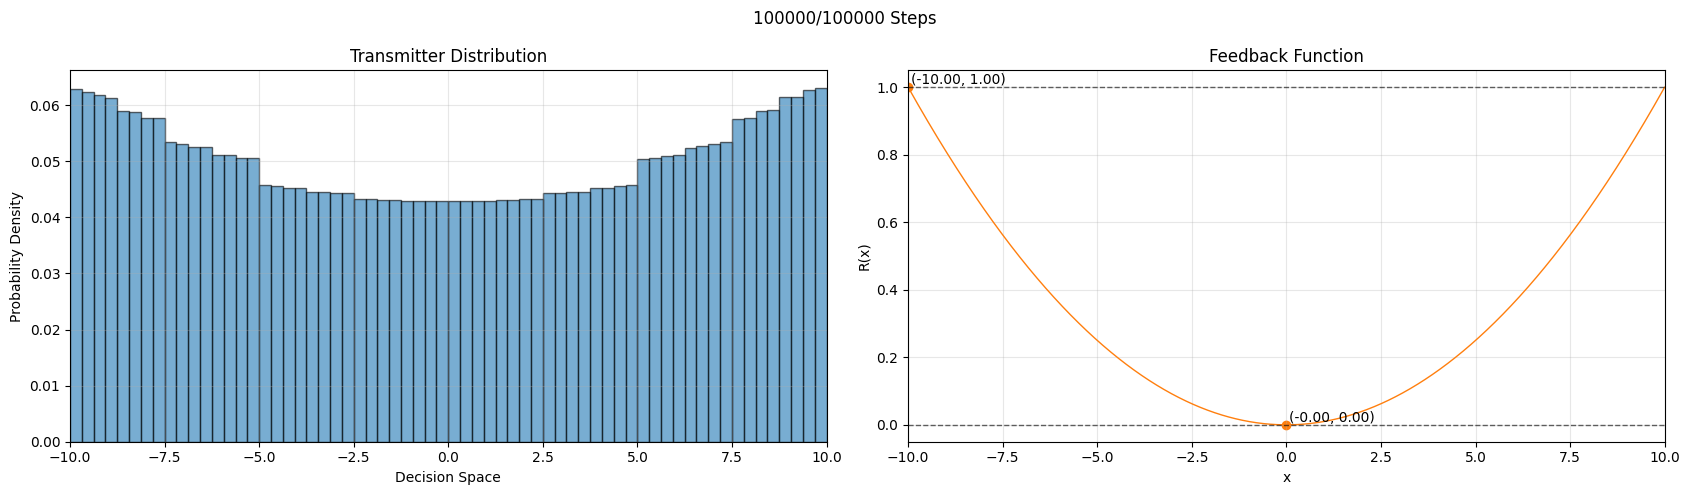

In [13]:
run(func)

Analogously, it is also possible to define the opposite environment through a negative quadratic function:

$$
R(x) : [-10, 10) \to [-1, 0]
$$

$$
R(x) = -\left(\frac{x}{10}\right)^2
$$

In this second case, moving away from the origin produces progressively more harmful rewards, causing decisions near the origin to become the most favorable within the decision space.

In [14]:
def func(x: float) -> float:
    """
    Negative quadratic function.

    Args:
        x (float): The input value.

    Returns:
        float: The output value.
    """
    y = -((x / 10.0) ** 2)
    return y

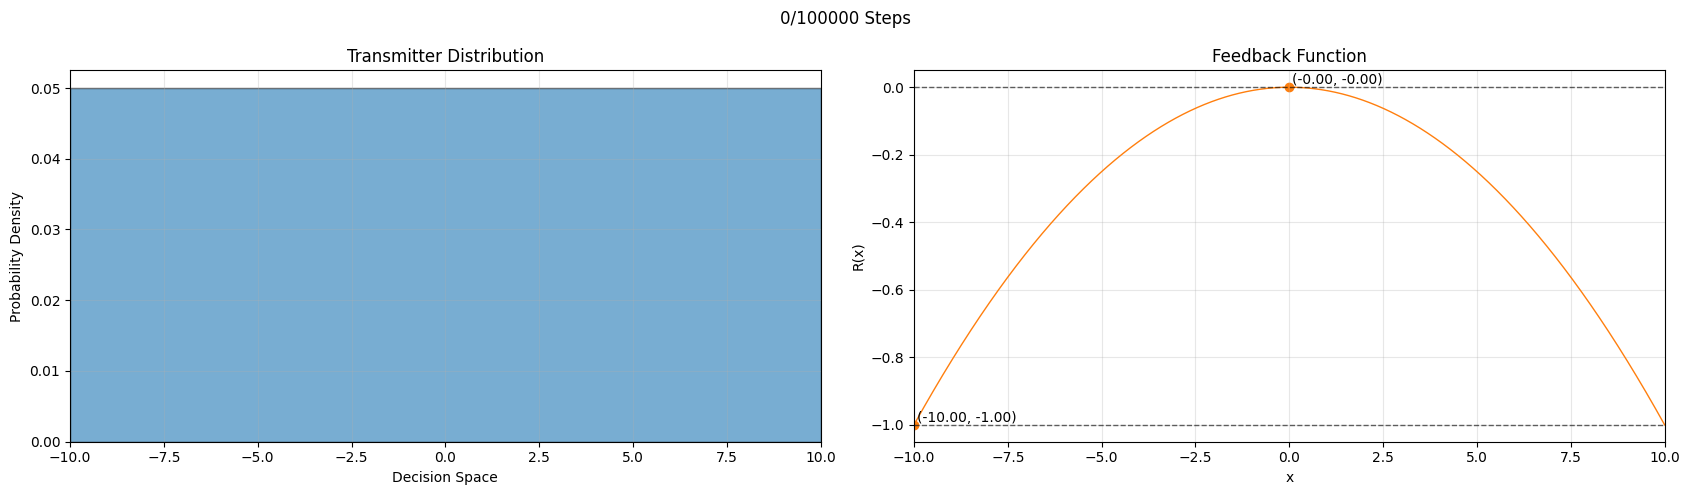

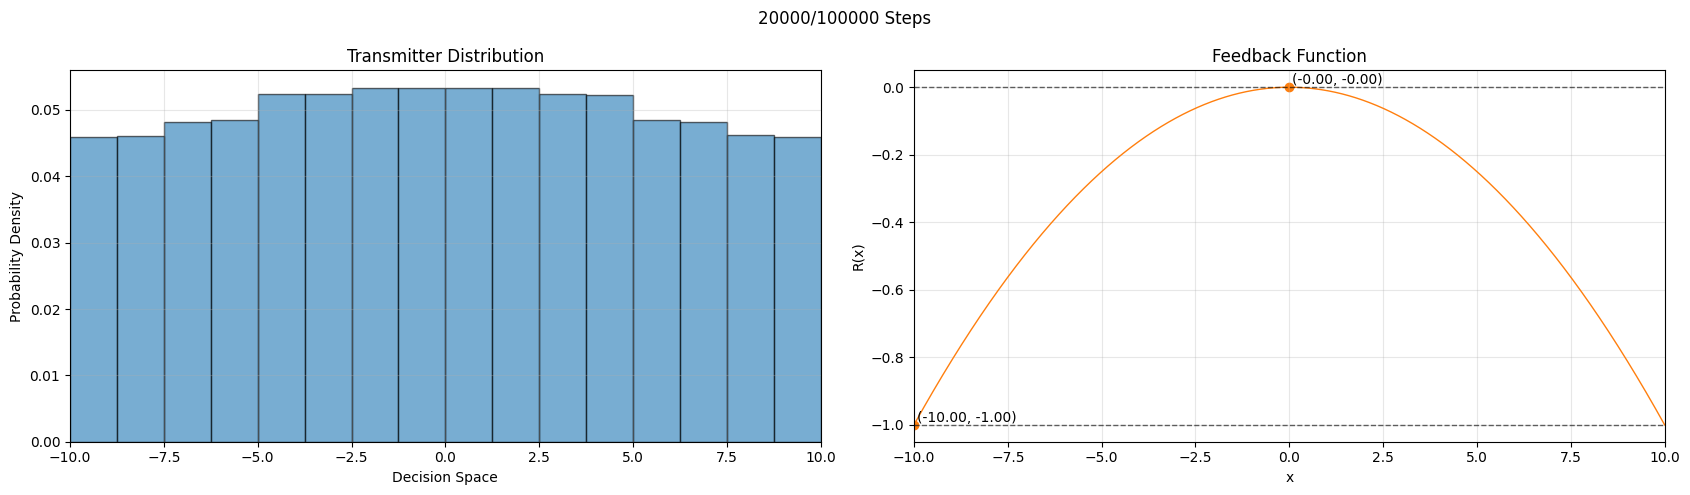

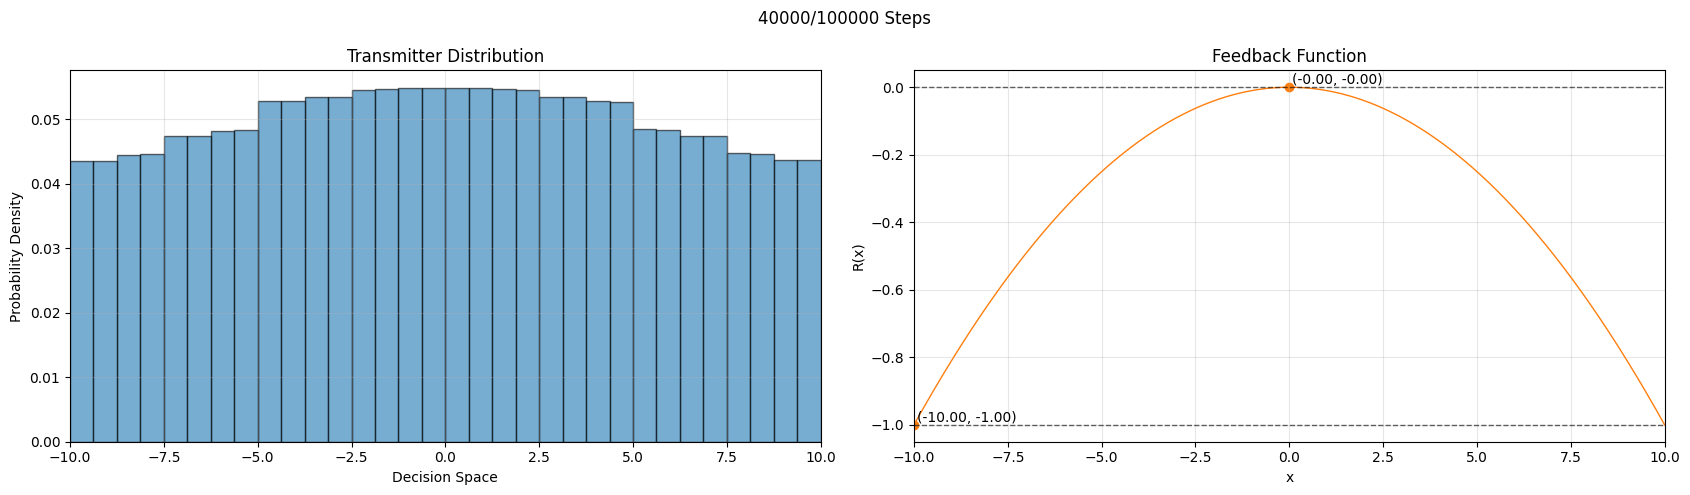

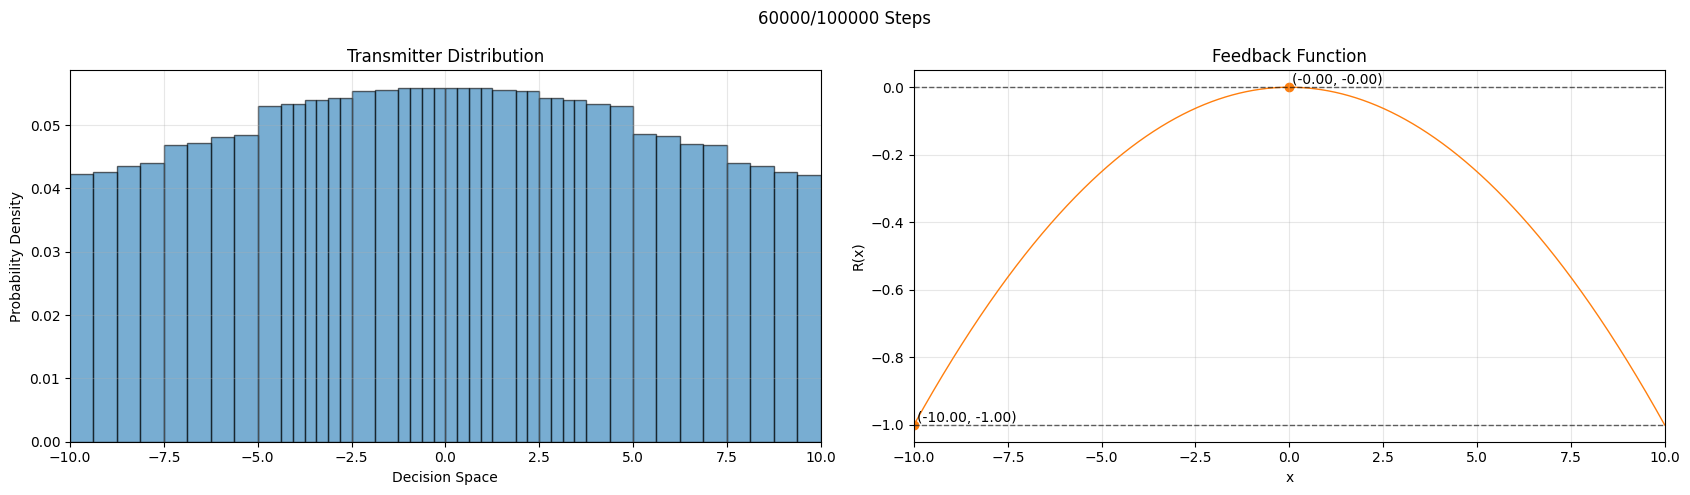

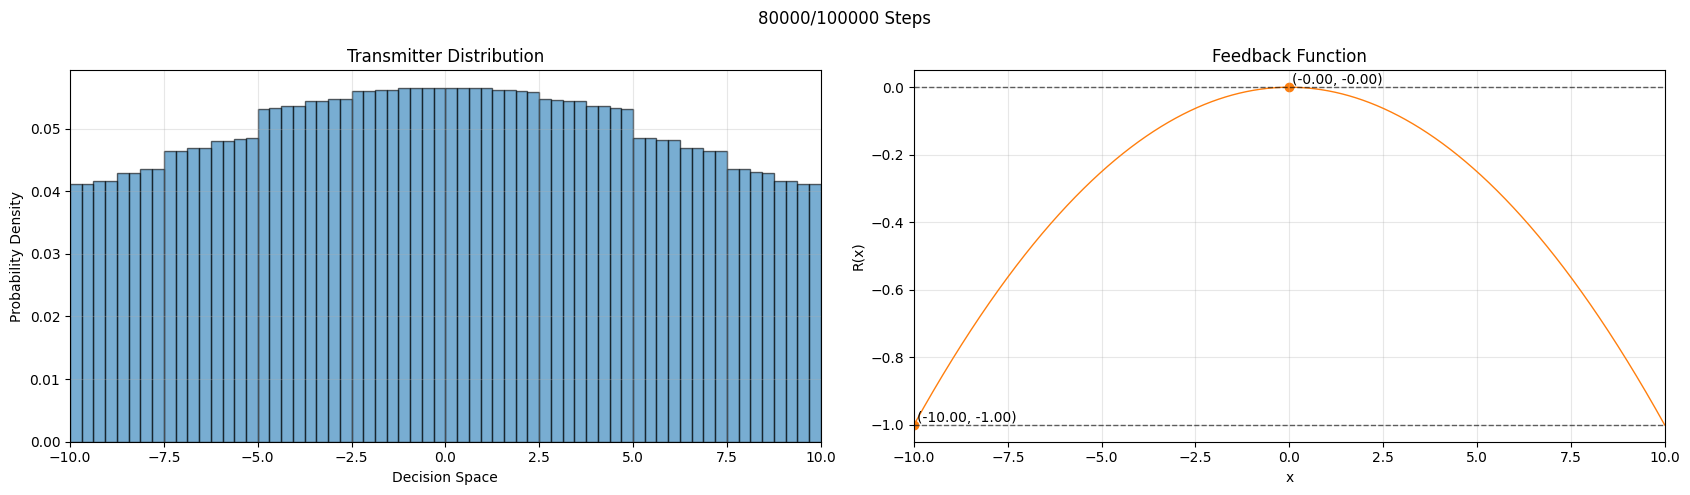

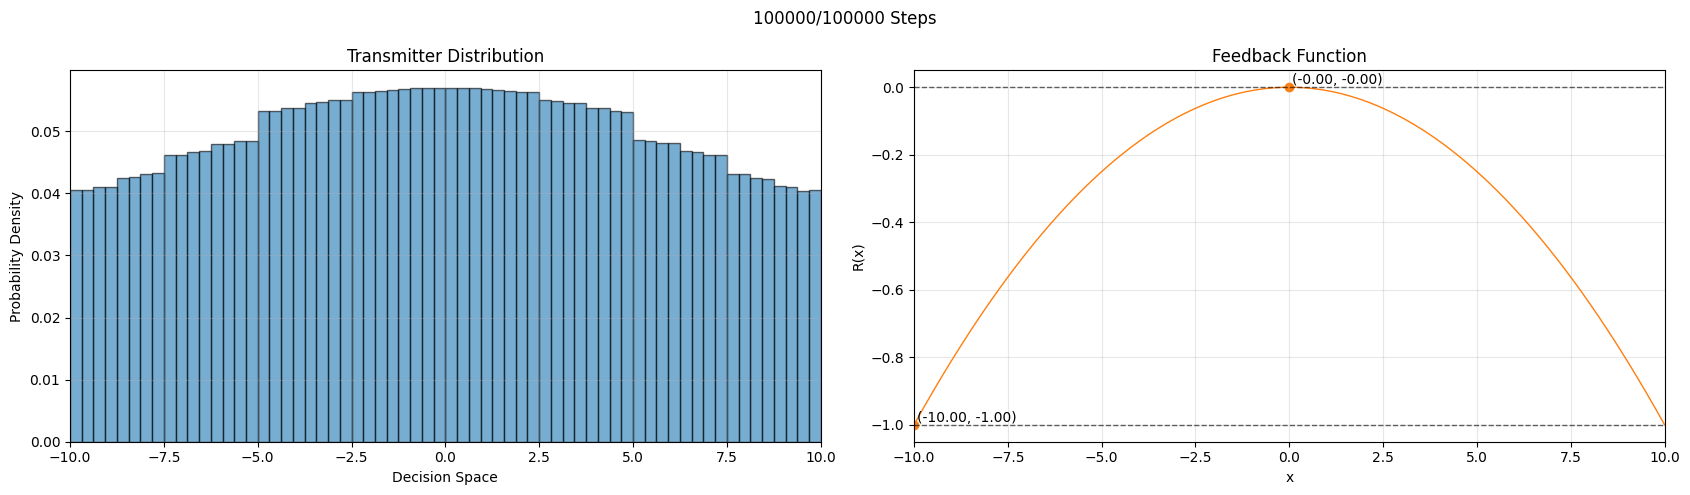

In [15]:
run(func)

### Multimodal Function

The previous environments exhibit relatively simple reward structures. Even when multiple favorable regions exist, as in the case of the positive quadratic function, the global geometry of the environment remains regular and easy to interpret.

However, in more complex environments, multiple local maxima and minima may coexist across the decision space. In such situations, the problem no longer consists solely in identifying favorable regions. The Transmitter must also avoid prematurely concentrating all its probability around suboptimal solutions which, although locally favorable, do not represent the best possible global outcome.

To represent this behavior, a damped sinusoidal function is used:

$$
R(x) : [-10, 10) \to [-1, 1]
$$

$$
R(x) = \sin(2x)\cdot e^{-0.05x^2}
$$

In [16]:
def func(x: float) -> float:
    """
    Sinusoidal function.

    Args:
        x (float): The input value.

    Returns:
        float: The output value.
    """
    y = math.sin(2 * x) * math.exp(-0.05 * x**2)
    return y

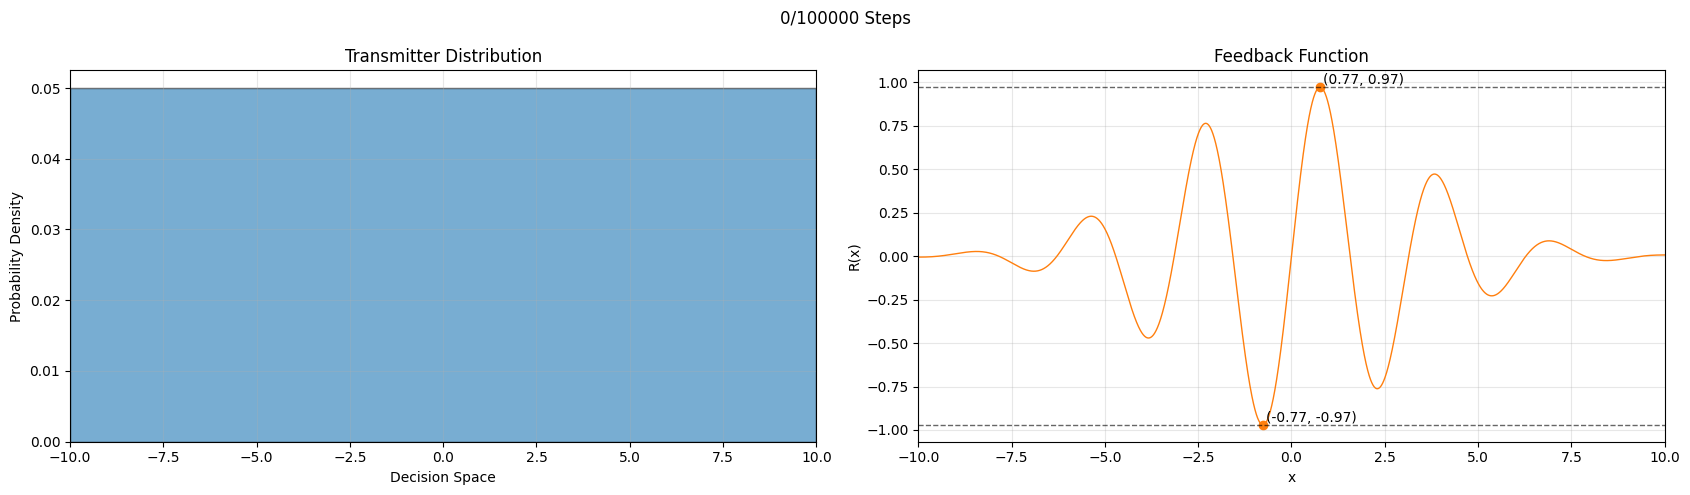

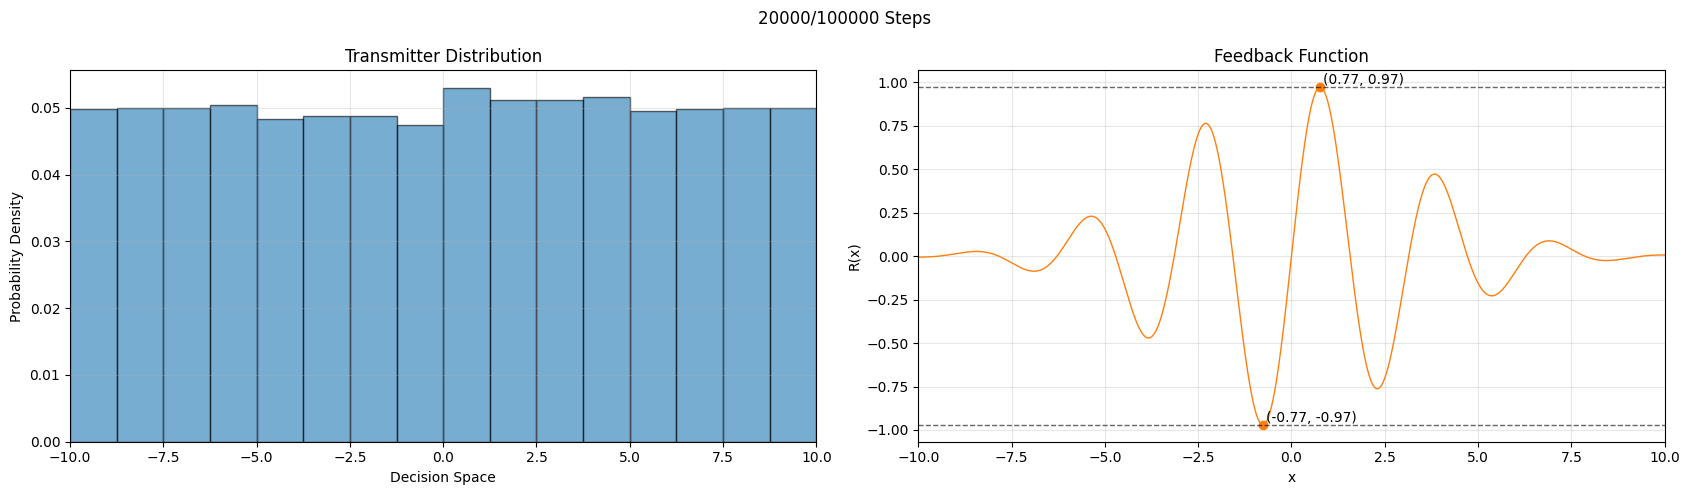

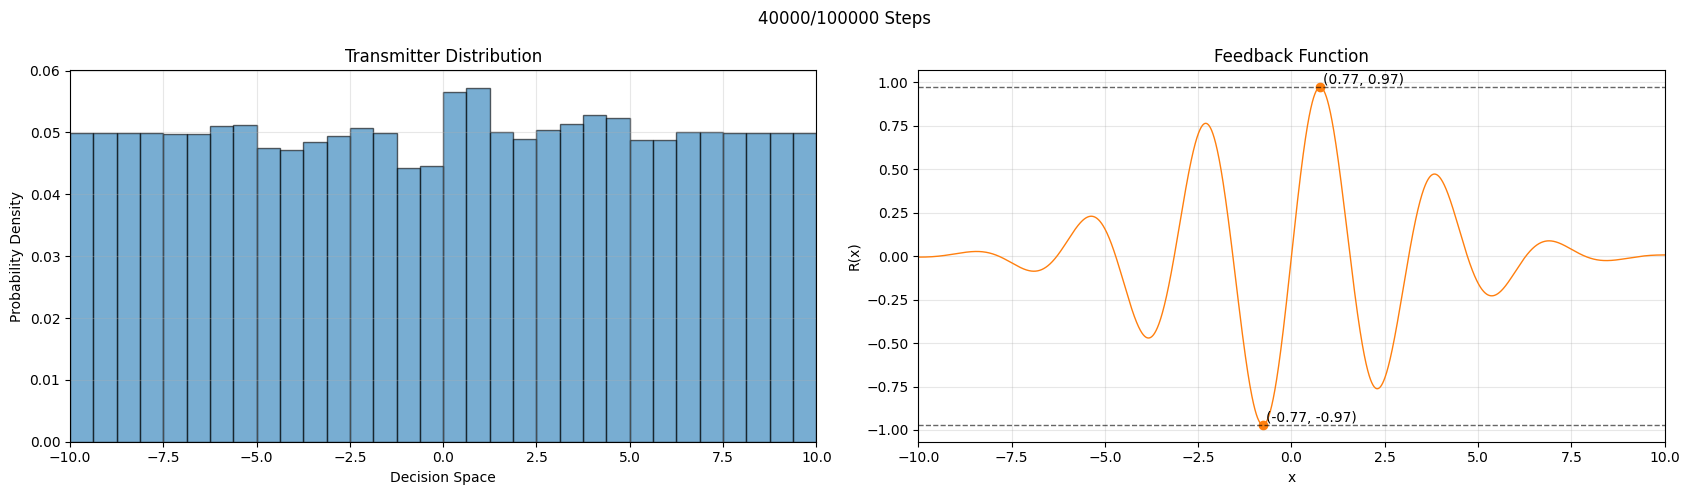

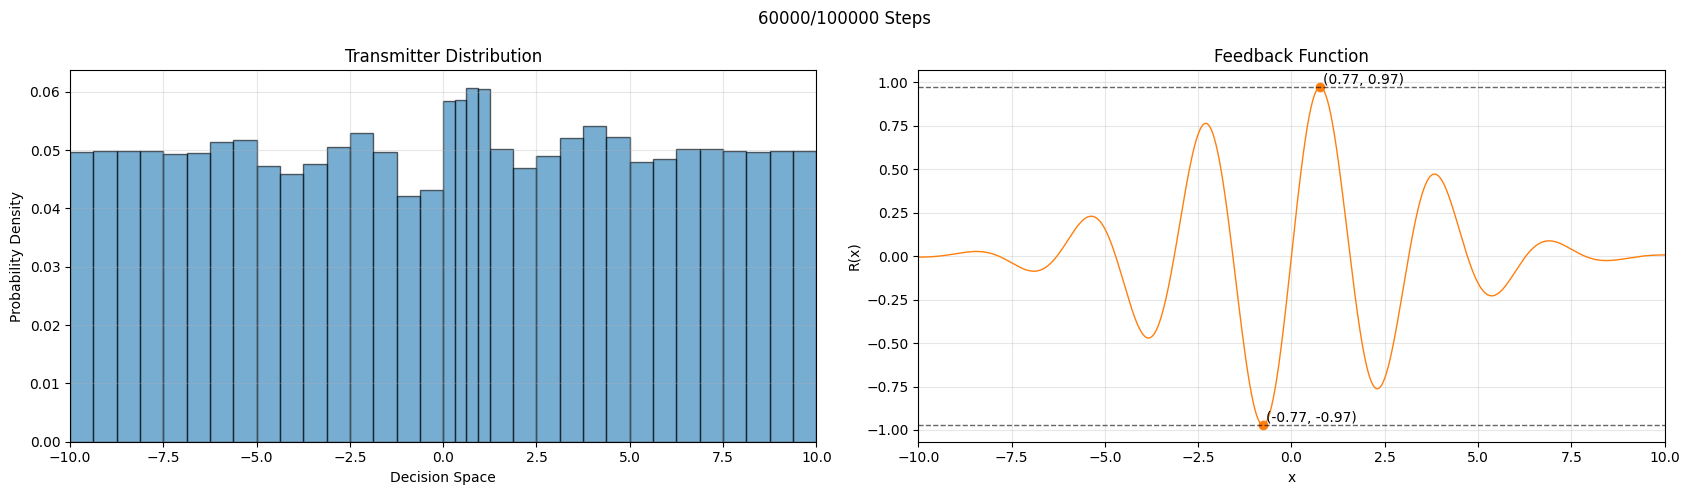

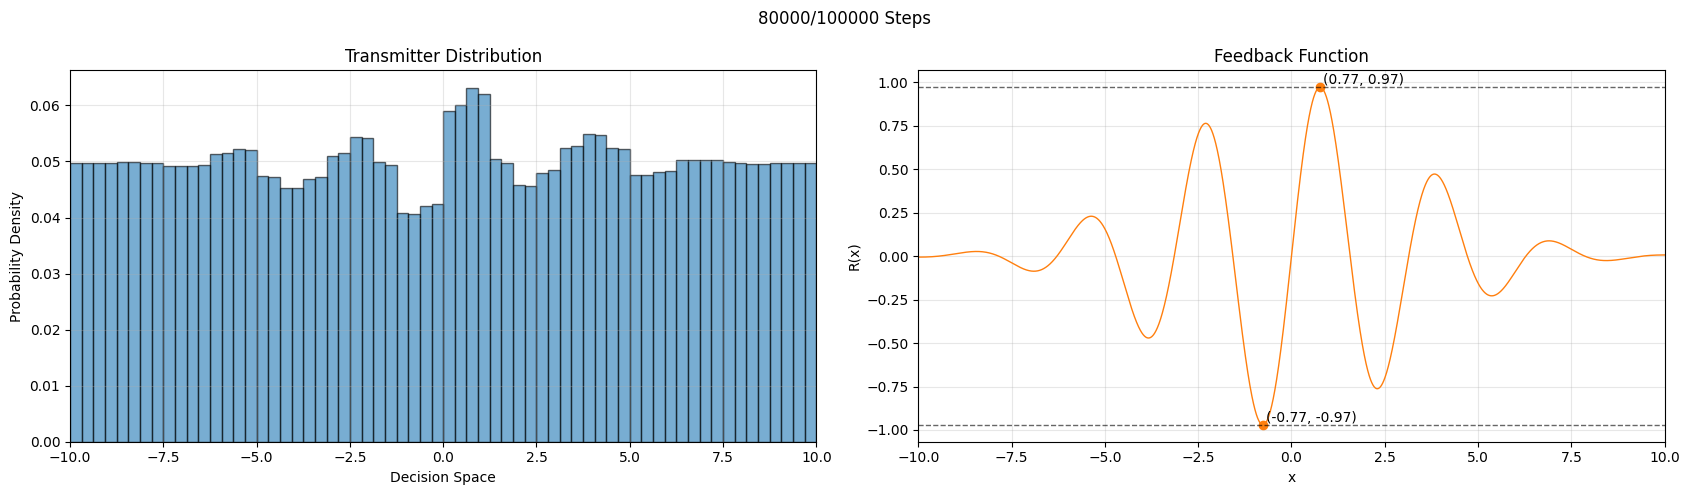

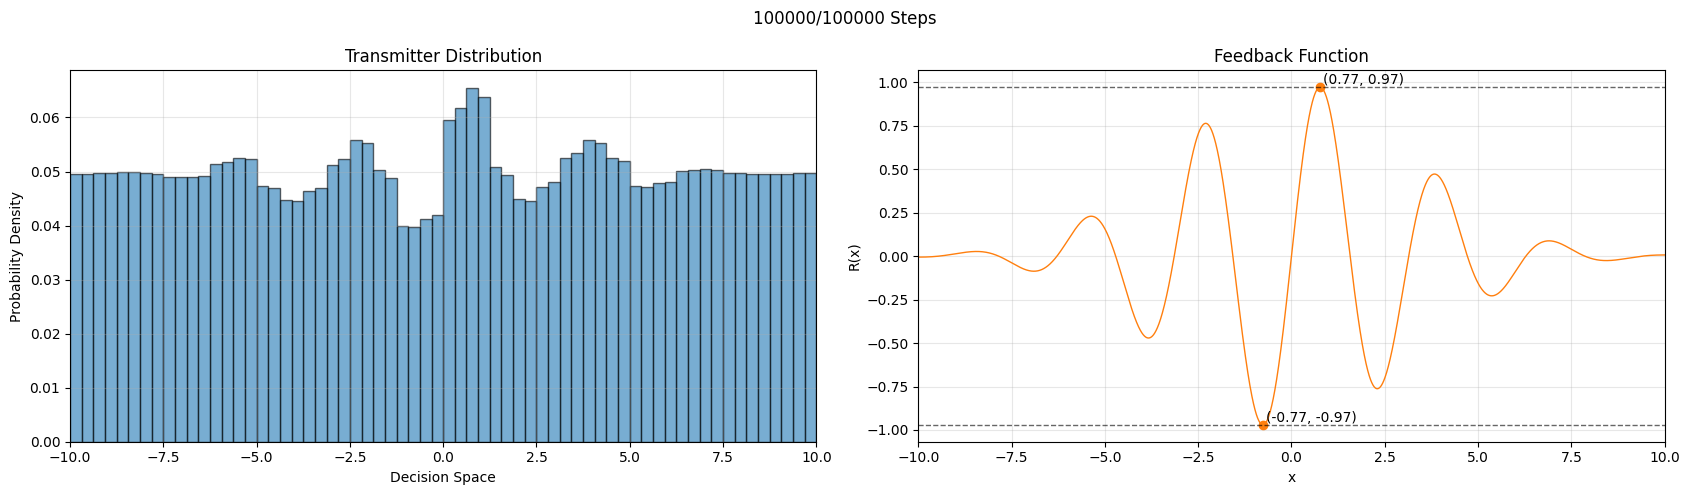

In [17]:
run(func)

## Influence of Bias on Transmitter Behavior

All previous experiments use a sampling bias equal to $0.0$. Under this configuration, the Transmitter generates samples directly from the learned probability distribution without artificially favoring any particular region of the decision space.

However, in many real-world systems, the balance between exploration and exploitation does not remain constant. In living organisms, for example, this balance may vary dynamically depending on the context. States of alertness, curiosity, play, or immediate survival alter the exploratory behavior of the organism and modify how it makes decisions about the environment.

The Transmitter bias acts precisely as an equivalent regulatory mechanism. Its purpose is not to modify the knowledge learned by the system, but rather to temporarily alter how that knowledge is explored during the sampling process.

More specifically:
- A positive bias intensifies the differences between regions of high and low probability, favoring exploitative behavior.
- A negative bias progressively reduces these differences, partially flattening the sampling probabilities and favoring exploration.
- For sufficiently negative values, low-probability regions even become explicitly favored over the dominant regions.
- A null bias preserves the natural behavior of the learned distribution.

As a consequence, bias makes it possible to dynamically modify the Transmitter's decision strategy without directly altering its internal probabilistic structure.

This mechanism becomes especially useful in complex environments with multiple local optima, where it may be necessary to temporarily increase exploration in order to avoid premature convergence toward suboptimal regions of the decision space.

In [18]:
def func(x: float) -> float:
    """
    Two-level step function.

    Args:
        x (float): The input value.

    Returns:
        float: The output value.
    """
    y = 1.0 if x >= 0.0 else -1.0
    return y

In [19]:
def plot_sampling_distribution(
    ax: plt.Axes,
    func: callable,
    transmitter: Transmitter,
    bias: float,
    interval: tuple[float],
    n_points: int,
) -> None:
    """
    Plot the sampling distribution.

    Args:
        ax (plt.Axes): The axes to plot on.
        func (callable): The function to plot.
        transmitter (Transmitter): The Transmitter to plot.
        bias (float): The bias to apply to the samples.
        interval (tuple[float]): The interval to plot the distribution over.
        n_points (int): The number of points to plot.
    """
    # evaluate the biased sampling distribution
    xs = [transmitter.forward(bias).value for point in range(n_points)]
    ys = [func(x) for x in xs]
    # plot the target distribution
    ax.scatter(xs, ys, color="C0", alpha=0.6)
    # general plot settings
    ax.set_xlim(interval[0], interval[1])
    ax.set_xlabel("x")
    ax.set_ylabel("R(x)")
    ax.set_title(f"Sampling Distribution (Bias: {bias:.2f})")
    ax.grid(True, linewidth=0.8, alpha=0.3)
    return

In [20]:
def run(func: callable) -> None:
    """
    Run the Transmitter for a given function.

    Args:
        func (callable): The function to run.
    """
    lr_scheduler = Scheduler(ConstantScheduleStrategy(LEARNING_RATE))
    hits_scheduler = Scheduler(ConstantScheduleStrategy(HITS_RATE))
    transmitter = Transmitter(
        INTERVAL[0], INTERVAL[1], lr_scheduler, hits_scheduler, seed=SEED
    )
    for _ in range(MAX_STEPS + 1):
        # forward & backward pass
        sample = transmitter.forward()
        feedback = func(sample.value)
        transmitter.backward(sample, feedback)
    # plot the Transmitter distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
    plot_transmitter_distribution(ax1, transmitter, INTERVAL)
    plot_target_distribution(ax2, func, INTERVAL, N_POINTS)
    plt.tight_layout()
    plt.show()
    # plot biased samples
    biases = [-1.0, -0.5, -0.25, 0.0, 0.5, 1.0]
    for _, bias in enumerate(biases):
        fig, ax = plt.subplots(1, 1, figsize=(17, 5))
        plot_target_distribution(ax, func, INTERVAL, N_POINTS)
        plot_sampling_distribution(ax, func, transmitter, bias, INTERVAL, N_POINTS)
        plt.tight_layout()
        plt.show()
    return

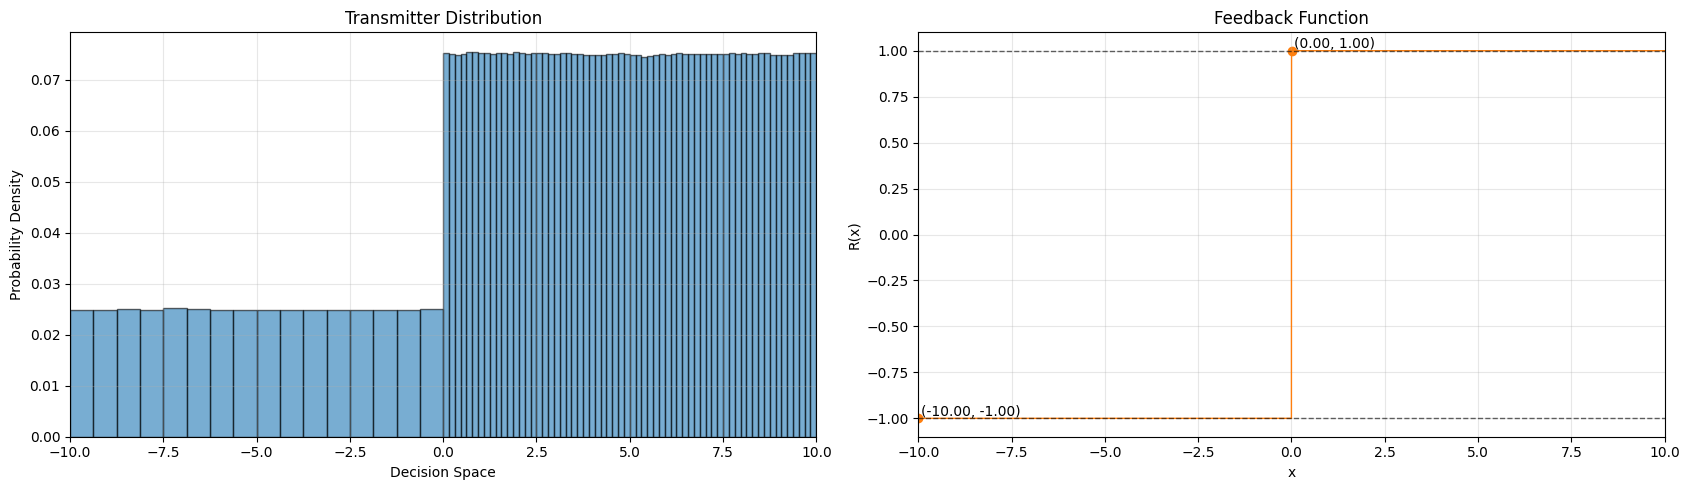

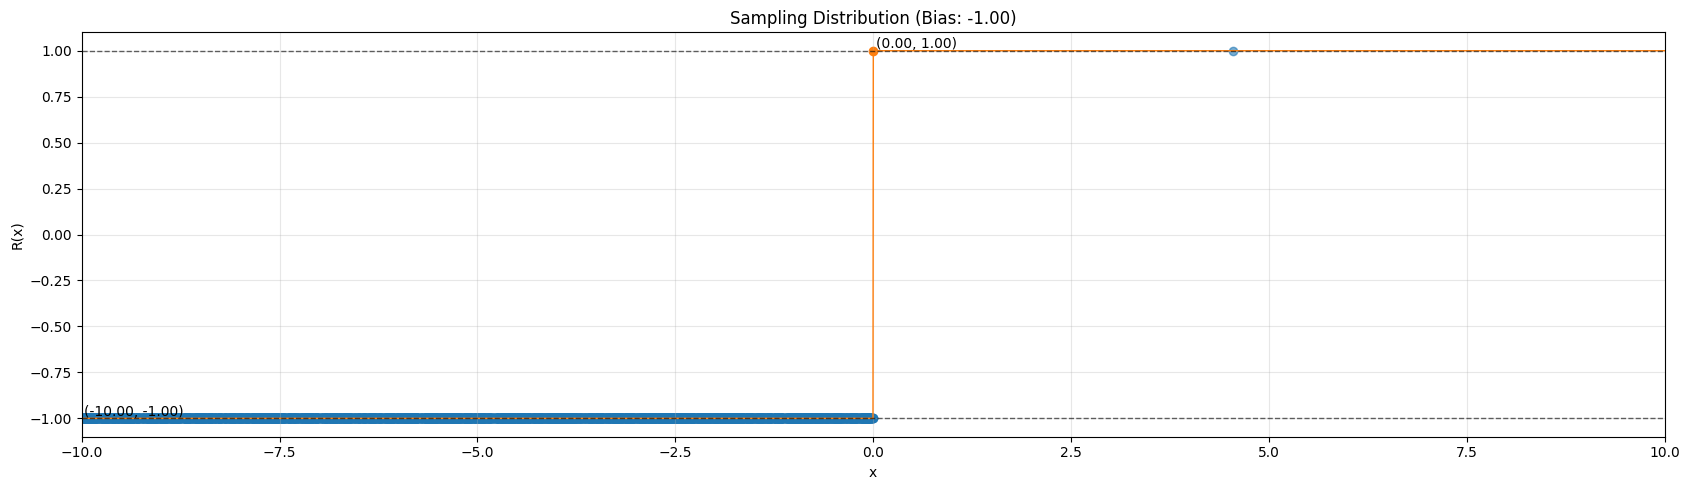

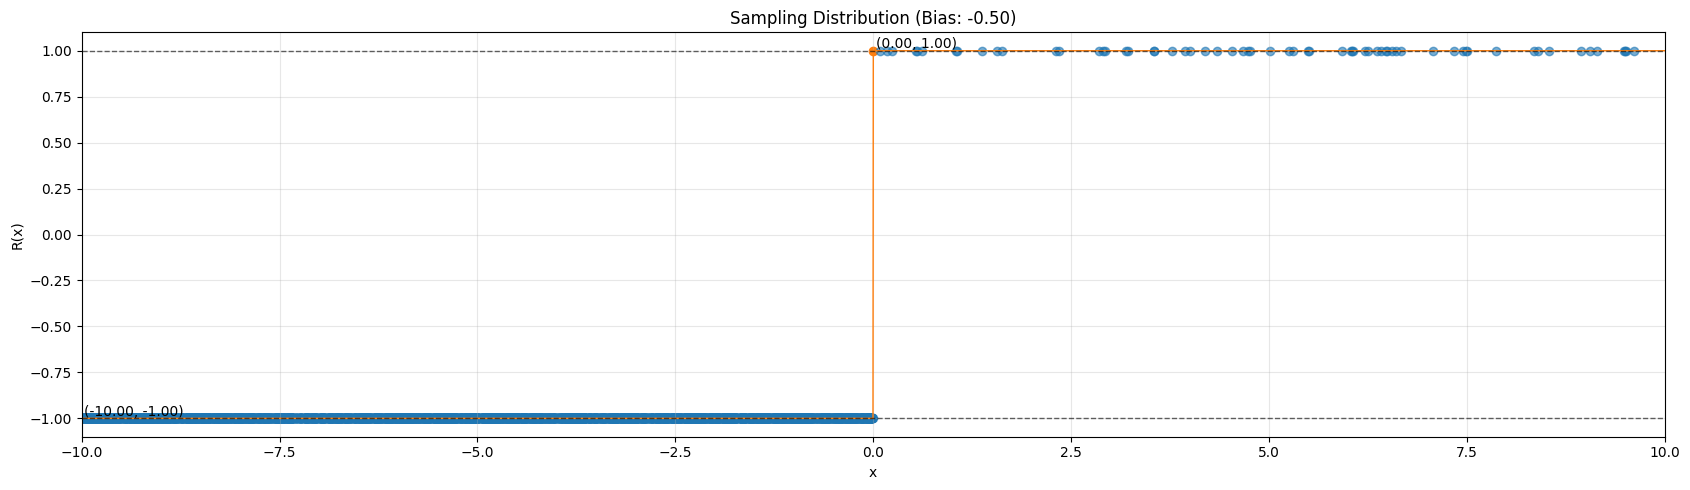

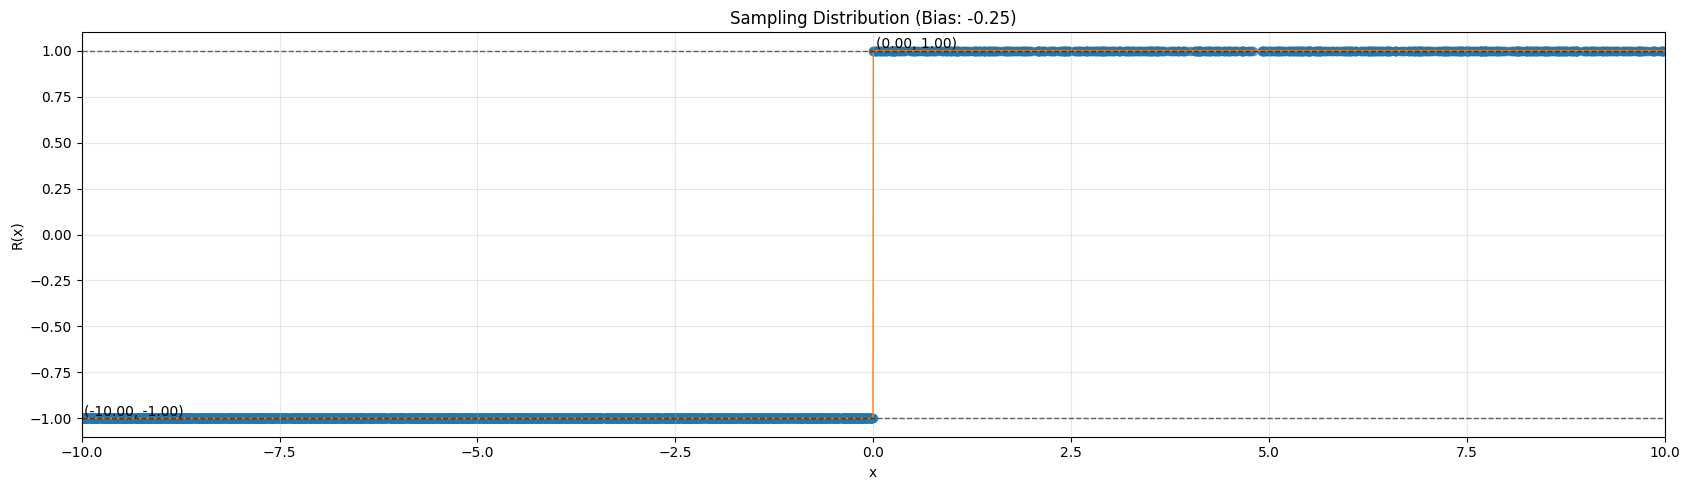

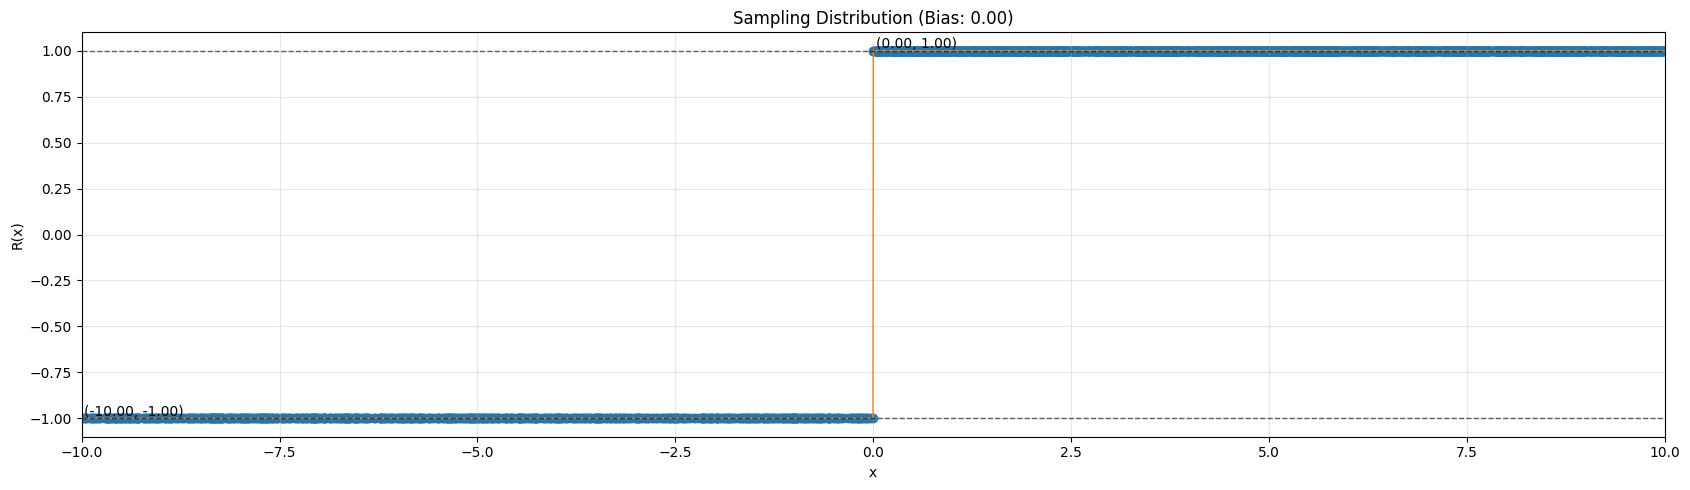

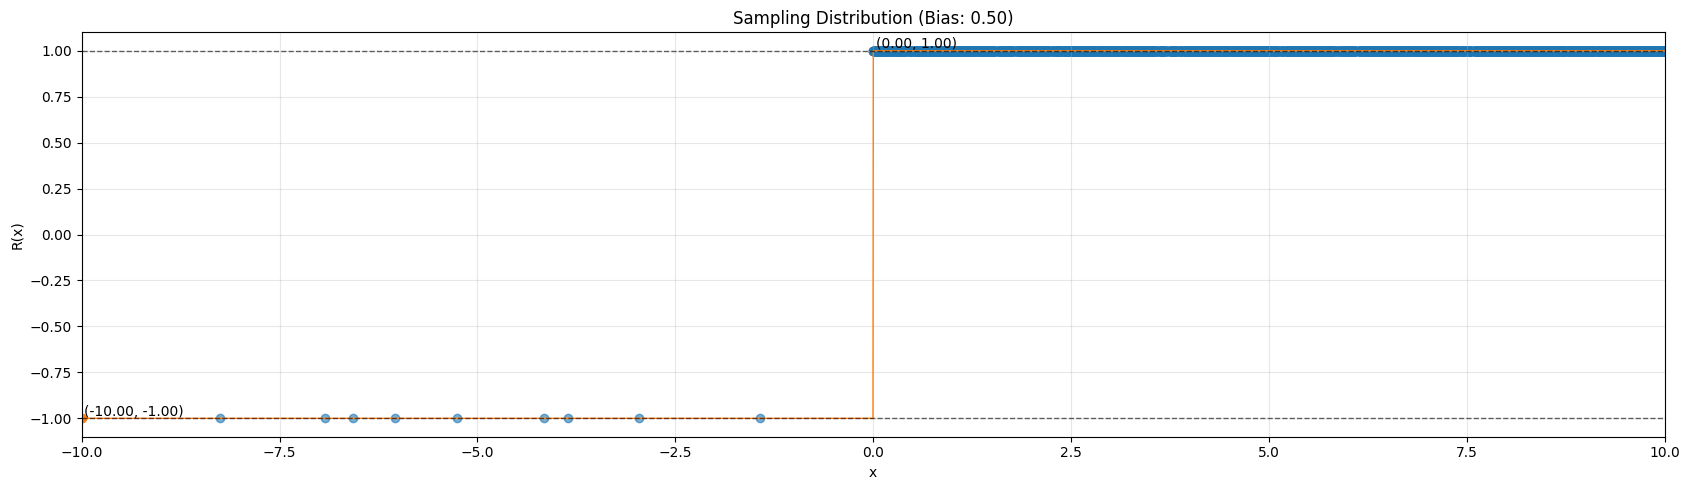

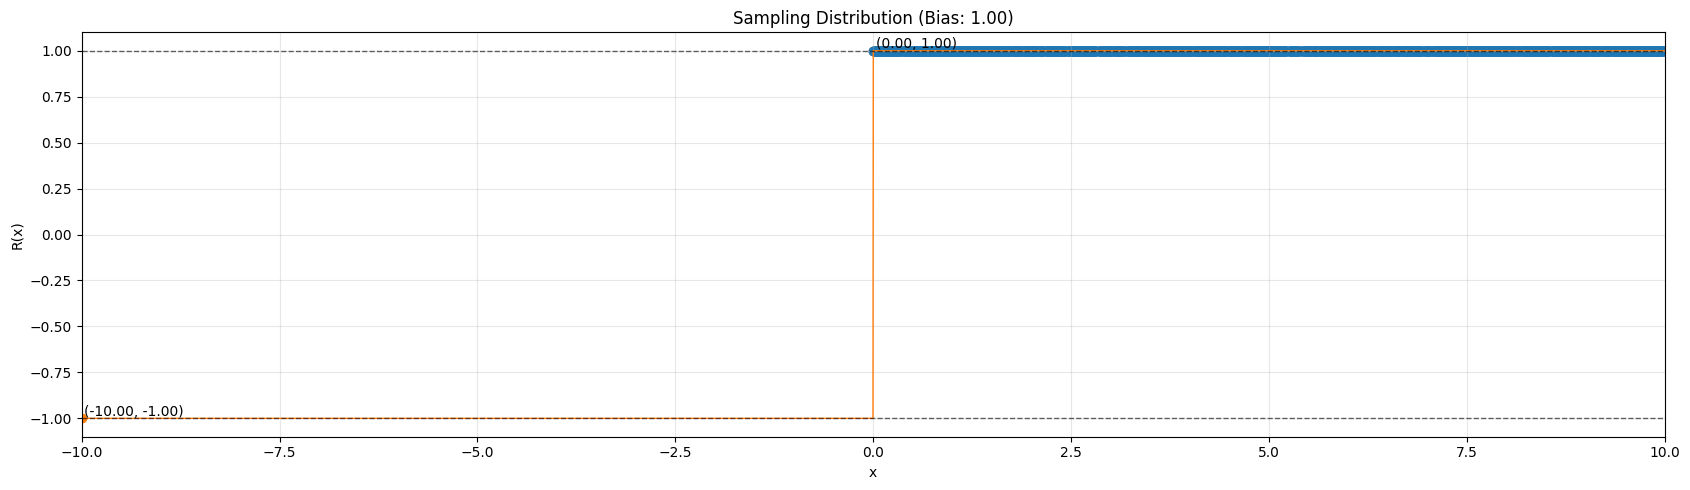

In [21]:
run(func)

## Conclusions

Throughout this playground, the behavior of the Transmitter has been evaluated under different decision-making environments with progressively increasing complexity.

The different experiments show how the system is capable of progressively reorganizing its probability distribution from accumulated experience, concentrating greater probability over those regions of the space associated with more favorable rewards.

As the complexity of the environment increases, the Transmitter preserves its adaptive capabilities without requiring predefined deterministic structures or explicit external exploration mechanisms. Both the exploration of the decision space and the exploitation of favorable regions emerge directly from the probabilistic dynamics of the system itself.

Finally, the introduction of dynamic sampling biases demonstrates that the balance between exploration and exploitation can be externally regulated without altering the knowledge learned by the system, allowing the decision strategy to be temporarily adapted to the context of the environment.

Taken together, the obtained results show that the Transmitter constitutes a probabilistic mechanism capable of progressively adapting to complex environments exclusively through experience and feedback.